# Basic Machine Learning algorithm testing

## Imports
The following libraries are imported for data manipulation and visualization:
- `pandas` for working with dataframes
- `numpy` for numerical operations
- `matplotlib` for data visualization
- `os` and `time` for system operations
- `sklearn` for algorithms and models
- `pytorch` for advanced models

In [129]:
import pandas as pd
import os

from gmpy2 import random_state
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import FunctionTransformer
import numpy as np
import time


# Data Prep-up
Firstly we need to import our numeric and categorical data (we use previous part to split the data with basic sklearn algorithm)

In [130]:
data = pd.read_csv("Spotify_Youtube.csv", encoding="utf-8")

test_proportion = 0.9 # declares what number of data will be dedicated to testing (higher = faster)

# clean-up of the data - removing urls, descriptions, itp.
columns_to_exclude = [col for col in data.columns if col == 'Unnamed: 0' or col.lower() == 'uri' or 'url_' in col.lower() or 'description' in col.lower() or col == '']
data = data[data.columns.difference(columns_to_exclude)]

if os.path.exists("estimates/estimated_data.csv"):
    os.remove("estimates/estimated_data.csv")
if os.path.exists("estimates/gating_model_comp.csv"):
    os.remove("estimates/gating_model_comp.csv")
if os.path.exists("estimates/balancing_comp.csv"):
    os.remove("estimates/balancing_comp.csv")

data.head()

,Acousticness,Album,Album_type,Artist,Channel,Comments,Danceability,Duration_ms,Energy,Instrumentalness,...,Liveness,Loudness,Speechiness,Stream,Tempo,Title,Track,Valence,Views,official_video
0,0.008360,Demon Days,album,Gorillaz,Gorillaz,169907.0,0.818,222640.0,0.705,0.002330,...,0.6130,-6.679,0.1770,1.040235e+09,138.559,Gorillaz - Feel Good Inc. (Official Video),Feel Good Inc.,0.772,693555221.0,True
1,0.086900,Plastic Beach,album,Gorillaz,Gorillaz,31003.0,0.676,200173.0,0.703,0.000687,...,0.0463,-5.815,0.0302,3.100837e+08,92.761,Gorillaz - Rhinestone Eyes [Storyboard Film] (...,Rhinestone Eyes,0.852,72011645.0,True
2,0.042500,New Gold (feat. Tame Impala and Bootie Brown),single,Gorillaz,Gorillaz,7399.0,0.695,215150.0,0.923,0.046900,...,0.1160,-3.930,0.0522,6.306347e+07,108.014,Gorillaz - New Gold ft. Tame Impala & Bootie B...,New Gold (feat. Tame Impala and Bootie Brown),0.551,8435055.0,True
3,0.000015,Plastic Beach,album,Gorillaz,Gorillaz,55229.0,0.689,233867.0,0.739,0.509000,...,0.0640,-5.810,0.0260,4.346636e+08,120.423,Gorillaz - On Melancholy Hill (Official Video),On Melancholy Hill,0.578,211754952.0,True
4,0.025300,Gorillaz,album,Gorillaz,Gorillaz,155930.0,0.663,340920.0,0.694,0.000000,...,0.0698,-8.627,0.1710,6.172597e+08,167.953,Gorillaz - Clint Eastwood (Official Video),Clint Eastwood,0.525,618480958.0,True


Now we need to state the Goal of our training model - for us it will be Streams on Spotify - as we would like to predict which song will be popular.

In [131]:
data = data.dropna(subset=['Stream']) # any NAs will be not valid

# getting categorical and numeric stats
numeric_stats = data.select_dtypes(include=['number'])
categorical_stats = data.select_dtypes(include=['object'])

numeric_stats.head()

,Acousticness,Comments,Danceability,Duration_ms,Energy,Instrumentalness,Key,Likes,Liveness,Loudness,Speechiness,Stream,Tempo,Valence,Views
0,0.008360,169907.0,0.818,222640.0,0.705,0.002330,6.0,6220896.0,0.6130,-6.679,0.1770,1.040235e+09,138.559,0.772,693555221.0
1,0.086900,31003.0,0.676,200173.0,0.703,0.000687,8.0,1079128.0,0.0463,-5.815,0.0302,3.100837e+08,92.761,0.852,72011645.0
2,0.042500,7399.0,0.695,215150.0,0.923,0.046900,1.0,282142.0,0.1160,-3.930,0.0522,6.306347e+07,108.014,0.551,8435055.0
3,0.000015,55229.0,0.689,233867.0,0.739,0.509000,2.0,1788577.0,0.0640,-5.810,0.0260,4.346636e+08,120.423,0.578,211754952.0
4,0.025300,155930.0,0.663,340920.0,0.694,0.000000,10.0,6197318.0,0.0698,-8.627,0.1710,6.172597e+08,167.953,0.525,618480958.0


It is better to exclude such stats as Youtube views, likes and comments as they reveal too much info.

In [132]:
columns_to_exclude = ["Views", "Comments", "Likes", "Stream"] # of course, we need to exclude our Goal stat as well

numeric_stats_reduced = numeric_stats.drop(columns = [col for col in columns_to_exclude if col in numeric_stats])
numeric_stats_reduced.head()

,Acousticness,Danceability,Duration_ms,Energy,Instrumentalness,Key,Liveness,Loudness,Speechiness,Tempo,Valence
0,0.008360,0.818,222640.0,0.705,0.002330,6.0,0.6130,-6.679,0.1770,138.559,0.772
1,0.086900,0.676,200173.0,0.703,0.000687,8.0,0.0463,-5.815,0.0302,92.761,0.852
2,0.042500,0.695,215150.0,0.923,0.046900,1.0,0.1160,-3.930,0.0522,108.014,0.551
3,0.000015,0.689,233867.0,0.739,0.509000,2.0,0.0640,-5.810,0.0260,120.423,0.578
4,0.025300,0.663,340920.0,0.694,0.000000,10.0,0.0698,-8.627,0.1710,167.953,0.525


Now it is time to create a pipeline - series of steps that will be used on data in order to prepare it for model-training. We use pipelines as they automatically remember the parameters of the data's transformations (ex. all previous artists in one-hot encoding as not to give 1 artist 2 different "ids").

In [133]:
X = pd.concat([numeric_stats_reduced, categorical_stats], axis=1) # we need to concat the data for the pipeline to use

X['Title'] = X['Title'].fillna('')

Y = numeric_stats["Stream"] # our Goal

numeric_features = numeric_stats_reduced.columns.tolist() # returns list of strings
categorical_features = categorical_stats.columns.tolist()
special_categorical_features = ['Title', 'Track', 'Album', 'Channel']

categorical_features = [col for col in categorical_features if col not in special_categorical_features] # we use different preprocessing for titles (safe version)
print( special_categorical_features in categorical_features)

False


We will need to add simple text concatenation tool for use in pipelines.

In [134]:
class TextConcatenator(BaseEstimator, TransformerMixin):
    def __init__(self, separator=" "):
        self.separator = separator

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.astype(str).agg(self.separator.join, axis=1).values

Now for the pipeline itself.

In [135]:

# for numeric data
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')), # if NA then fill with mean
    ('scaler', StandardScaler()) # then normalize
])

# for categorical data
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # if NA then fill with most frequent
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

# special transformer for titles - we use tf-idf which is more advanced than one-hot (makes wages for words based on their popularity) and output them to 50 features
title_transformer = Pipeline([
    ('concat', TextConcatenator()), # will output like "title track album"
    ('tfidf', TfidfVectorizer(max_features=1000)),
    ('svd', TruncatedSVD(n_components=50, random_state=42)) # 'PCA' for sparse matrixes
])

# for categorical data with PCA reduction
categorical_transformer_PCA = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # if NA then fill with most frequent
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ('pca', PCA(n_components=100)) # we use PCA algorithm to reduce size of the data - so memory usage as well
])

We also need to do a ColumnTransformer.

In [136]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
        ('title', title_transformer, special_categorical_features)
    ]
)

# with PCA reduction - used for testing
preprocessor_PCA = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer_PCA, categorical_features),
    ]
)

And now we need to split our data for training usage and examination usage.

In [137]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=test_proportion, random_state=40
)
X_train = X_train.reset_index(drop=True)
X_train.sort_index()
y_train = y_train.reset_index(drop=True)
y_train.sort_index()
X_test = X_test.reset_index(drop=True)
X_test.sort_index()
y_test = y_test.reset_index(drop=True)
y_test.sort_index()

0        140786187.0
1        107436637.0
2         89466323.0
3         41796649.0
4          1670944.0
            ...     
18123     55681213.0
18124     18889247.0
18125     21150746.0
18126     82660328.0
18127      1594253.0
Name: Stream, Length: 18128, dtype: float64

Let's also add simple function to save our results in csv.

In [138]:

def save_model_results(model_name, res_train, res_test, csv_path='estimated_data.csv', reset=False, *, classification=False):
    """
    Saves result (name, MSE, R²) to CSV.

    Parameters:
    csv_path: str – CSV filepath
    model_name: str – ex. 'Linear Regression'
    res_train - tuple with (MSE,R²)
    """
    if not classification:
        if(res_train is not None):
            new_row = {

                'Model': model_name,
                'MSE_Train': res_train[0],
                'R2_Train': res_train[1],
                'MSE_Test': res_test[0],
                'R2_Test': res_test[1]
            }
        else:
            new_row = {

                'Model': model_name,
                'MSE_Test': res_test[0],
                'R2_Test': res_test[1]
            }
    else:
        new_row = {
            'Model': model_name,
            'Accuracy_Train': res_train[0],
            'Recall_Train': res_train[1],
            'Accuracy_Test': res_test[0],
            'Recall_Test': res_test[1]
        }

    os.makedirs('estimates', exist_ok=True)
    full_path = os.path.join('estimates', csv_path)

    if os.path.exists(full_path) and not reset:
        df = pd.read_csv(full_path)
        df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
    else:
        df = pd.DataFrame([new_row])

    df.to_csv(full_path, index=False)
    print(f"Saved to {full_path}")


And a function for testing.

In [139]:
def getResult(prediction, actual):
    mse = mean_squared_error(actual, prediction)
    r2 = r2_score(actual, prediction)
    return mse,r2

# 1. Basic Sklearn Models

### Data prep-up
All good so far. Let's build first basic models based on: Linear Regression, Random Forrest and SVR (Support Vector Regressor) as well as SGD (Stochastic Gradient Regressor).

In [140]:
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor), # our preprocessing
    ('model', LinearRegression())
])

pipeline_lr_pca = Pipeline(steps=[
    ('preprocessor', preprocessor_PCA), # for comparison
    ('model', LinearRegression())
])

pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

pipeline_svr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SVR(kernel='rbf', C=10.0, epsilon=0.05)) # rbf for not-linear correlations
])

pipeline_sgd = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SGDRegressor(loss='squared_error', learning_rate='constant', eta0=0.01, random_state=42, max_iter=15000, tol=1e-4, shuffle=True)),
])

### Training

Now let's train it.

In [141]:
pipelines=[
    ('Linear Regression' ,pipeline_lr.fit(X_train, y_train)), # train on training set
    ('Linear Regression with PCA', pipeline_lr_pca.fit(X_train, y_train)),
    ('Random Forest', pipeline_rf.fit(X_train, y_train)),
    ('Support Vector Regressor', pipeline_svr.fit(X_train, y_train)),
    ('Stochastic Gradient Descent',pipeline_sgd.fit(X_train, y_train))
    ]

### Estimation

And now the estimation.

In [142]:
predictions = {}
for name, model in pipelines:
    predictions[name] = model.predict(X_train), model.predict(X_test)

### Results

Let's see how they did.

In [143]:

for name, _ in pipelines:
    train_res = getResult(predictions[name][0], y_train)
    test_res = getResult(predictions[name][1], y_test)
    print(f"{name:<25} | MSE: {test_res[0]:,.0f} | R²: {test_res[1]:.4f}")
    save_model_results(name, train_res, test_res)


Linear Regression         | MSE: 65,339,058,589,091,352 | R²: -0.0872
Saved to estimates\estimated_data.csv
Linear Regression with PCA | MSE: 56,779,661,184,870,648 | R²: 0.0552
Saved to estimates\estimated_data.csv
Random Forest             | MSE: 55,894,624,807,319,104 | R²: 0.0700
Saved to estimates\estimated_data.csv
Support Vector Regressor  | MSE: 67,686,093,460,306,232 | R²: -0.1262
Saved to estimates\estimated_data.csv
Stochastic Gradient Descent | MSE: 55,193,073,006,751,808 | R²: 0.0816
Saved to estimates\estimated_data.csv


### Takeaways:
1. Linear Regression - surprisingly the simplest algorithm got the best score in estimation.
2. Random Forest - still pretty good accuracy.
3. SVR - as we can see this way was even worse then guessing a value based on a mean (r2<0). It is not really a surprise as our data contains a lot of outliers that SVR doesn't really take into account.
4. SGD - very close to normal (closed) Linear Regression.

Let's visualize some of the estimations.

In [144]:
def draw_chart(estimation, name: str, seed=12, *, true_set=y_test, save=True):
    # random 10 titles
    sample = X_test.sample(n=10, random_state=seed)

    titles = sample['Title'].fillna('No title').astype(str)

    titles_short = titles.apply(lambda x: (x[:30] + '...') if len(x) > 30 else x)

    sample_pos = sample.index.to_numpy()

    true_values = true_set.iloc[sample_pos]
    pred_values = estimation[sample_pos]

    plt.figure(figsize=(12, 6))
    plt.plot(titles_short, true_values, marker='o', label='Actual Streams')
    plt.plot(titles_short, pred_values, marker='o', label='Estimated Streams')
    plt.xlabel('Title')
    plt.ylabel('Streams')
    plt.title(f'{name} - Estimated vs Actual Streams')
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    if save:
        os.makedirs('estimates/charts', exist_ok=True)
        plt.savefig(f'estimates/charts/{name}_chart.png')
    plt.show()




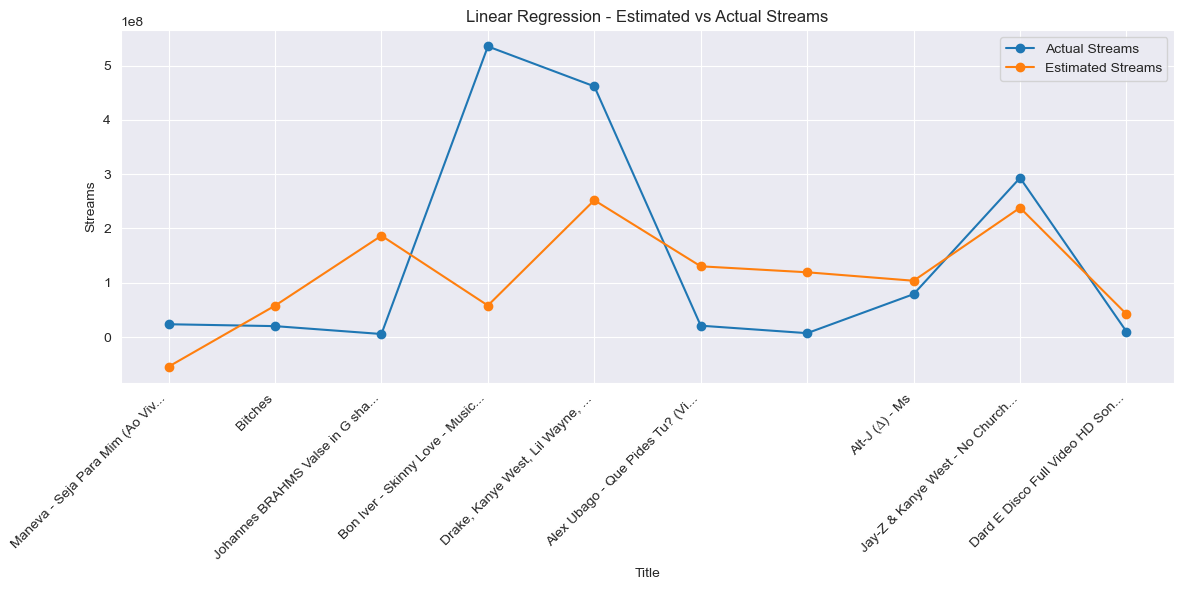

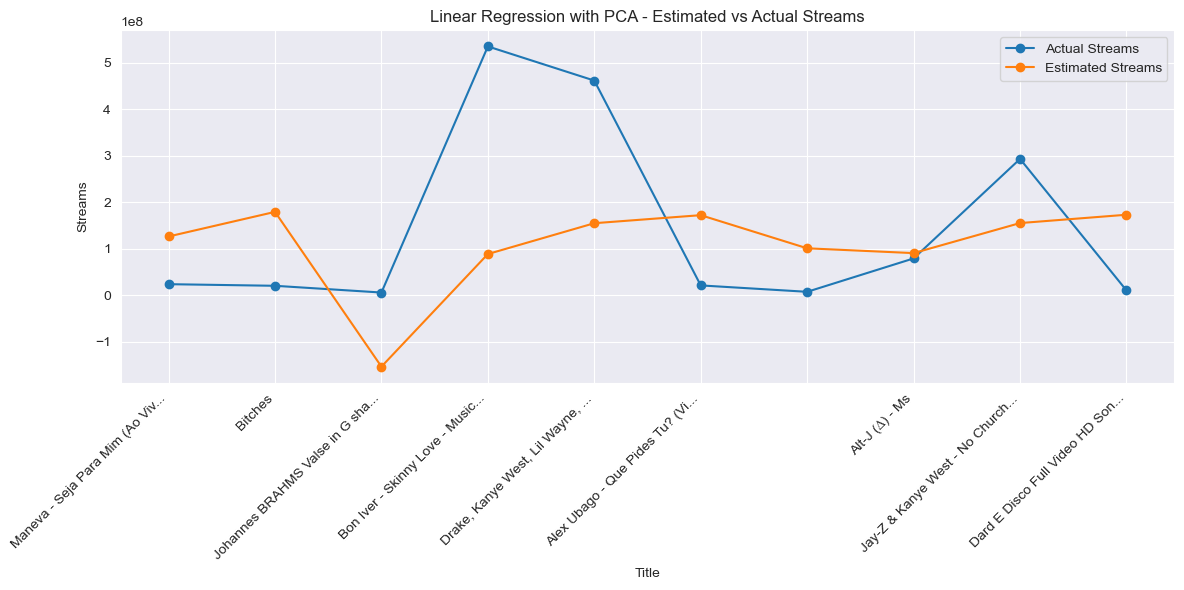

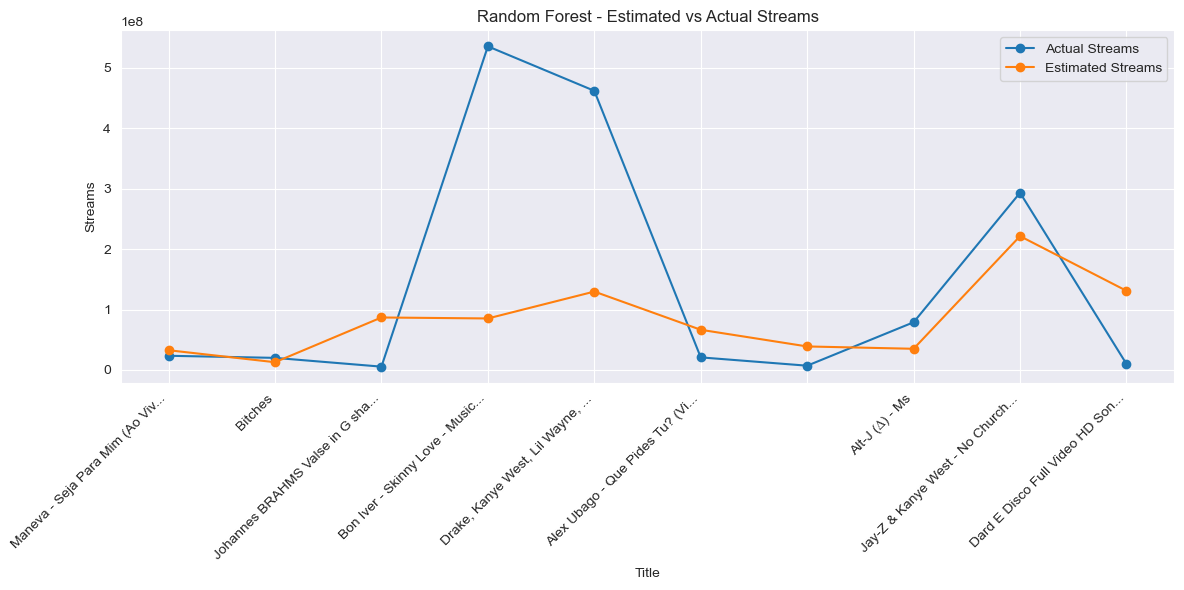

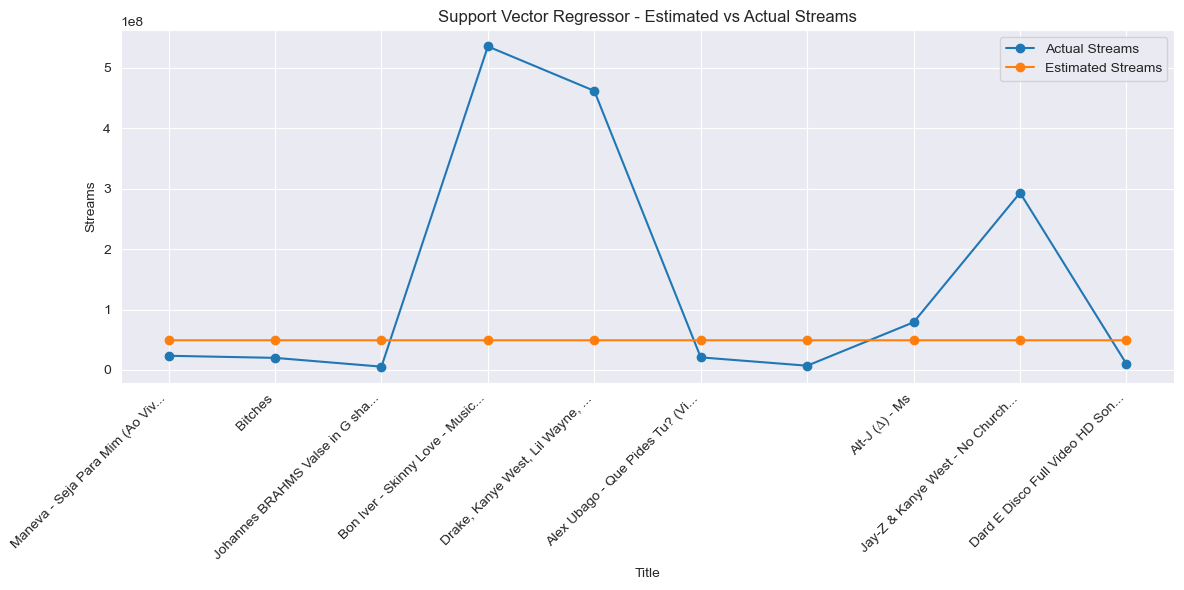

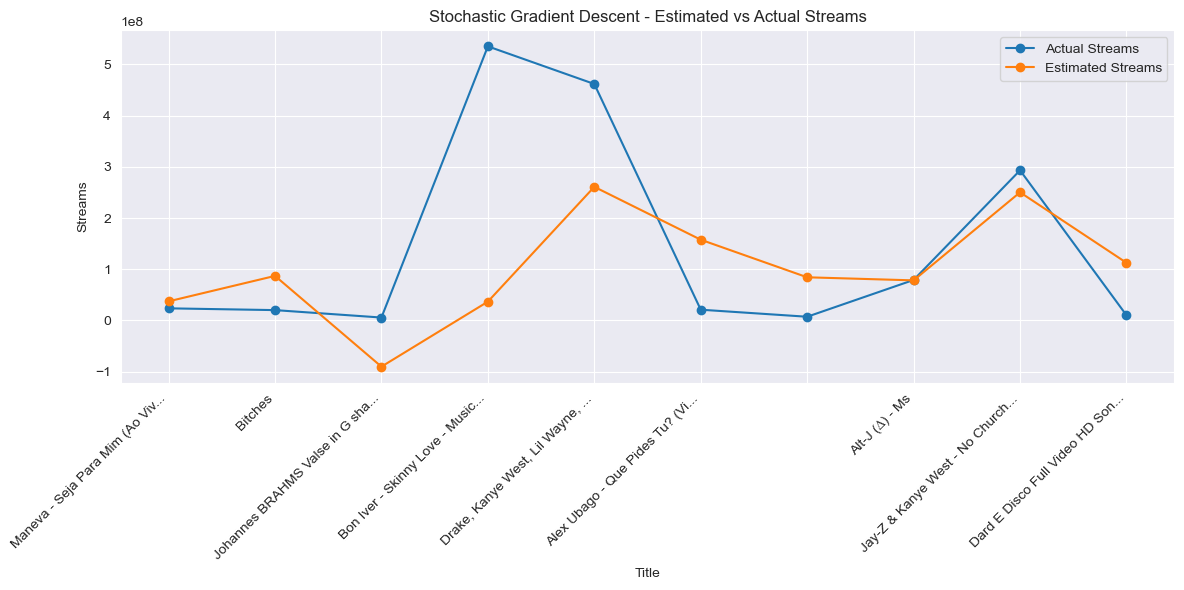

In [145]:
for name, _ in pipelines:
    draw_chart(predictions[name][1], name)

# 2 - Own Implementation: Closed Linear Regression / Gradient Descent

### Data Prep-up
Now let's try to implement basic Linear Regression using only numpy. First we need to add bias - this will help us determine the offset from 0,0 point (normal b in linear function).

In [146]:
X_train_proc = preprocessor.fit_transform(X_train) # transform to one-hot encode and normalize
X_train_proc_pca = preprocessor_PCA.fit_transform(X_train) # same but with PCA added
X_train_proc = X_train_proc.toarray()
X_train_b = np.hstack([np.ones((X_train_proc.shape[0], 1)), X_train_proc])
X_train_b_pca = np.hstack([np.ones((X_train_proc_pca.shape[0], 1)), X_train_proc_pca]) # this will make the computing automatic, as w0 - first wage will be equal to offset from the OX (b).

X_test_proc = preprocessor.transform(X_test)
X_test_proc_pca = preprocessor_PCA.transform(X_test)
X_test_proc = X_test_proc.toarray()
X_test_b = np.hstack([np.ones((X_test_proc.shape[0], 1)), X_test_proc])
X_test_b_pca = np.hstack([np.ones((X_test_proc_pca.shape[0], 1)), X_test_proc_pca]) # we must add bias to test data as well

## Closed Linear Regression

### Training

Now some math's - There are 2 functions we need to consider during Linear Regression:
1. Cost function - this will help model understand whether it's making progress in the right direction.
2. Linear function itself - a basic linear function with offset (b).

For us:
Linear function = b (bias) + w1 (wage) * x1 (parameter) + w2 * x2 + ....

Cost function = C(w) = || X (parameter's matrix) ⋅ w (wage vector) - y (actual value) ||^2 - so basically distance between estimated and real value

Now if we solve Cost function's derivative for w, we get:

w = (XT (transposed) ⋅ X) ^ (-1) ⋅ XT ⋅ y

So now to the code.

In [147]:
def closed_linear_regression(X_t, y_t):
    XtX = X_t.T @ X_t # Transposed * matrix (correlation matrix)

    XtX_inv = np.linalg.pinv(XtX) # Matrix inversion (using SVM to get results that are close to actual, while still using One-hot)

    XtY = X_t.T @ y_t # Second part of the equation

    return XtX_inv @ XtY # last part - result (optimal wages)

### Results

After following the equation we now have most optimal wages for our model - so we basically did the "fitting" part manually. Now let's see results.

In [148]:
w_closed = closed_linear_regression(X_train_b, y_train)

y_pred_closed = X_test_b @ w_closed
y_pred_train = X_train_b @ w_closed

test_res = getResult(y_pred_closed, y_test)
train_res = getResult(y_pred_train, y_train)

print(f"Own Linear Regression | MSE: {test_res[0]:,.0f} | R²: {test_res[1]:.4f}")
save_model_results( "Own closed Linear Regression", train_res, test_res)

Own Linear Regression | MSE: 65,340,525,602,277,672 | R²: -0.0872
Saved to estimates\estimated_data.csv


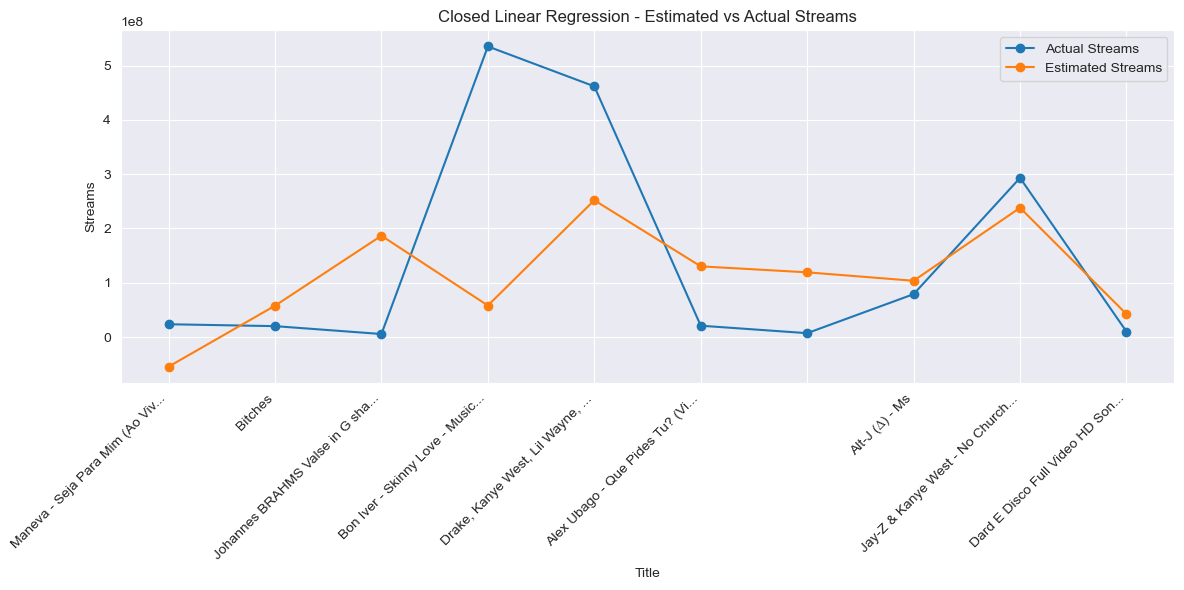

In [149]:
draw_chart(y_pred_closed, "Closed Linear Regression")

As we can see the results are pretty close to the previous (sklearn) Linear Regression - most likely because of different SVM implementations (or QR utilization).

So now we can analyze the drawbacks of this closed method :
1. It takes a very long time, as it has O(n^3) time complexity.
2. Can take a lot of memory if used on very large data sets.
3. Doesn't work for more complex (not-linear) models.

### Gradient Descent

With gradient approach - basics remain the same (aka. main functions - Linear Regression and bias). The change comes with Cost functions that is now a bit different:

Cost function (MSE) = 1/2n * ||X⋅w - y||^2 -> so we basically make a mean out of our previous function

So derivative (gradient) from this function is:

∇C(w) = 1/n * XT ⋅ (X⋅w − y)

So the whole concept of this approach is to move in the direction that ensures error reduction (contrary to gradient).

In [150]:
def gradient_descent(X, y, w_init, learning_rate=0.01, *, iterations=1000, epsilon=None, batch_size=32, X_test=None , y_test=None):
    n = len(y)
    w = w_init.copy()
    cost_history = []
    cost_history_test = []

    for i in range(iterations):
        # random choices for batch
        batch_indices = np.random.choice(n, size=batch_size, replace=False)
        X_batch = X[batch_indices]
        y_batch = y[batch_indices]

        predictions = X_batch @ w

        gradient = (1 / batch_size) * (X_batch.T @ (predictions - y_batch))

        w = w - learning_rate * gradient # wages actualisation
        full_predictions = X @ w
        cost = mean_squared_error(y, full_predictions)
        cost_history.append(cost)
        if X_test is not None and y_test is not None:
            test_predictions = X_test @ w
            cost_test = mean_squared_error(y_test, test_predictions)
            cost_history_test.append(cost_test)

        if epsilon is not None and i > 0:
            if abs(cost_history[-2] - cost_history[-1]) < epsilon:
                print(f"Stopped early at iteration {i} (change < epsilon={epsilon})")
                break

    return w, cost_history, cost_history_test


### Training

So let's take this function for a spin.

In [151]:
w_grad, cost_history, cost_history_test = gradient_descent(X_train_b, y_train, np.zeros(X_train_b.shape[1]), iterations=5000, X_test=X_test_b, y_test=y_test) # initialize w with random values

Ok, now the "fitting" part is done. We actually can see how it searched for the minimum.

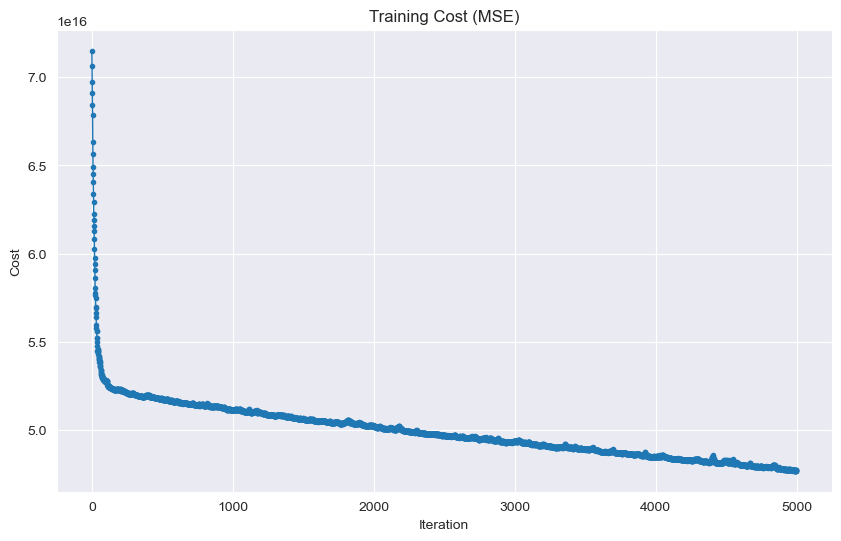

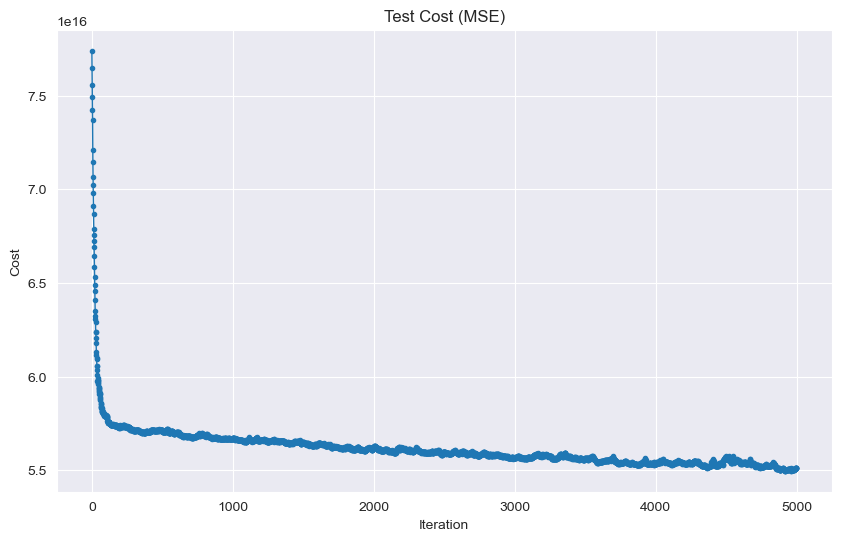

In [152]:
def draw_fitting_chart(cost_history, name='Cost MSE', save=True):
    plt.figure(figsize=(10, 6))
    plt.plot(cost_history, marker='o', markersize=3, linewidth=1)
    plt.title(name)
    plt.xlabel("Iteration")
    plt.ylabel("Cost")
    plt.grid(True)
    if save:
        os.makedirs('estimates/fitting_charts', exist_ok=True)
        plt.savefig(f'estimates/fitting_charts/{name}_fit_chart.png')
    plt.show()

draw_fitting_chart(cost_history, name='Training Cost (MSE)')
draw_fitting_chart(cost_history_test, name='Test Cost (MSE)')

### Results

And now for the results.

In [153]:
y_pred_grad = X_test_b @ w_grad
y_pred_train = X_train_b @ w_grad

train_res = getResult(y_pred_train, y_train)
test_res = getResult(y_pred_grad, y_test)

print(f"Own Gradient Descent | MSE: {test_res[0]:,.0f} | R²: {test_res[1]:.4f}")
save_model_results("Own Gradient Descent", train_res, test_res)

Own Gradient Descent | MSE: 55,136,673,283,257,816 | R²: 0.0826
Saved to estimates\estimated_data.csv


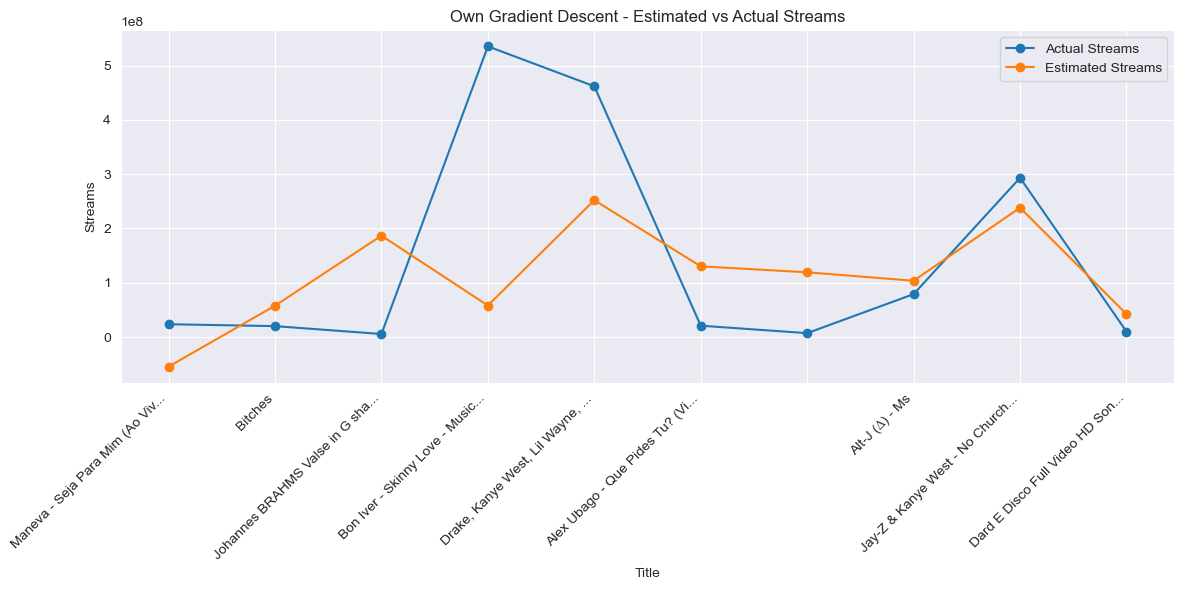

In [154]:
draw_chart(y_pred_closed, "Own Gradient Descent")

In [155]:
def plot_metric_from_csv(csv_path, column_name, save=True, name='default'):
    """
    Makes plot from csv file of column name.

    Parameters:
    - csv_path: str – path to csv file
    - column_name: str – ex. 'MSE_Train', 'MSE_Test', 'R2_Train', 'R2_Test'
    """
    df = pd.read_csv(csv_path)

    if column_name not in df.columns:
        raise ValueError(f"Column not found '{column_name}' in CSV.")

    models = df['Model']
    values = df[column_name]

    plt.figure(figsize=(12, 6))

    x_pos = range(len(models))

    plt.scatter(x_pos, values, s=100, color='tab:blue')

    plt.title(f"{column_name} for Models")
    plt.xlabel("Model")
    plt.ylabel(column_name)
    plt.xticks(x_pos, models, rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    if save:
        os.makedirs('estimates/plot_charts', exist_ok=True)
        plt.savefig(f'estimates/plot_charts/{name}_plot_chart.png')
    plt.show()

## Comparison

If we would like to compare results of our own implementation to the one from sklearn, here we can see that.

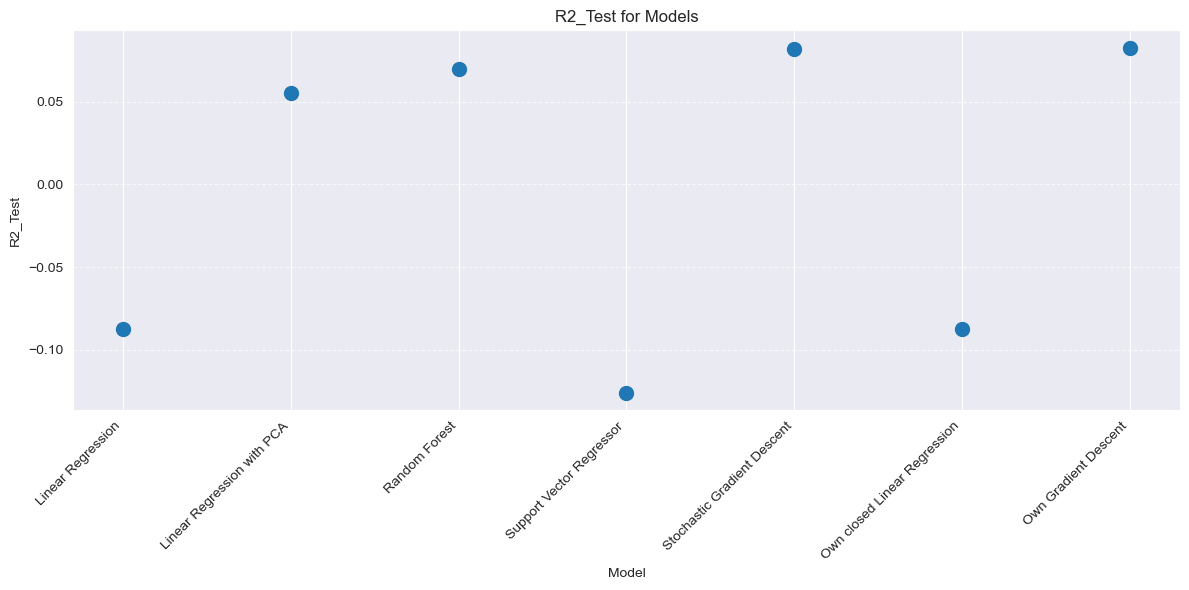

In [156]:
plot_metric_from_csv('estimates/estimated_data.csv','R2_Test')

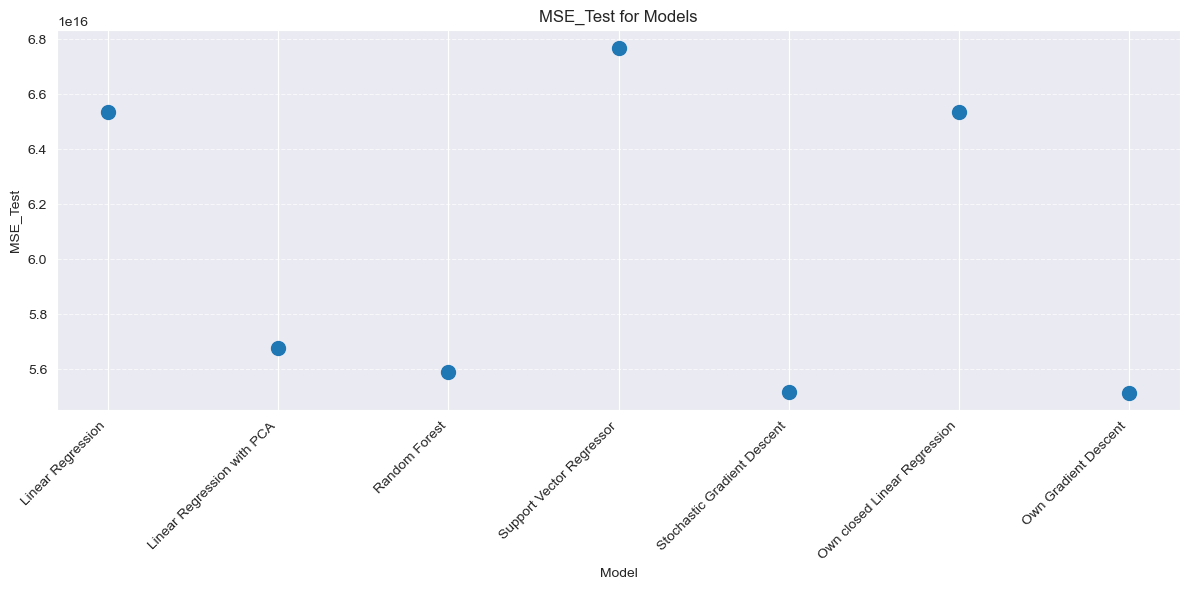

In [157]:
plot_metric_from_csv('estimates/estimated_data.csv','MSE_Test')

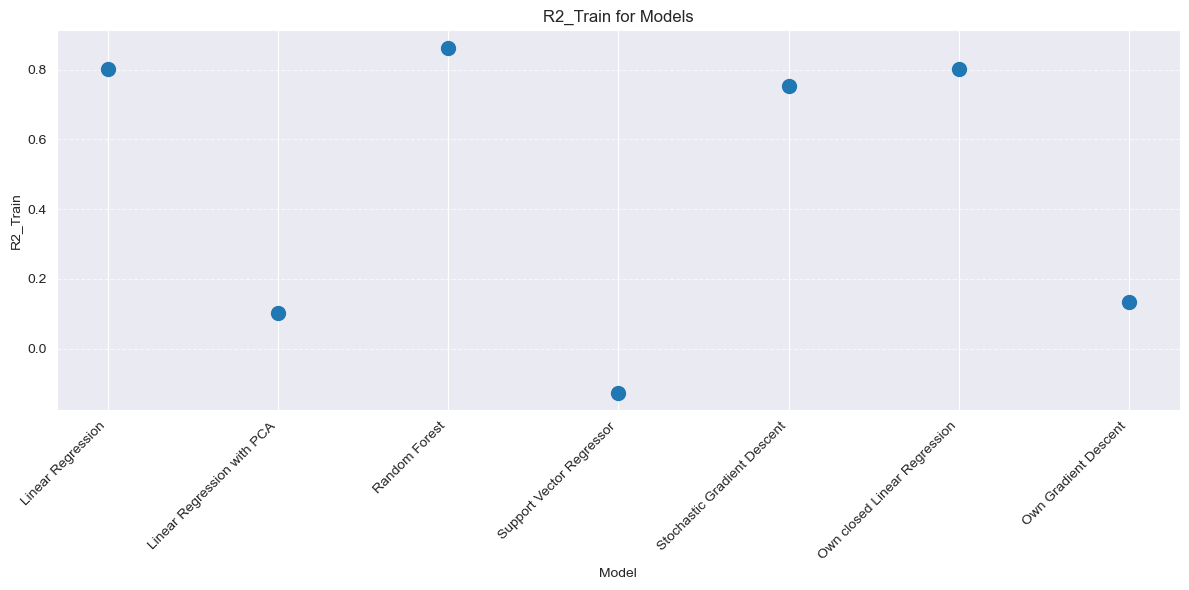

In [158]:
plot_metric_from_csv('estimates/estimated_data.csv','R2_Train')

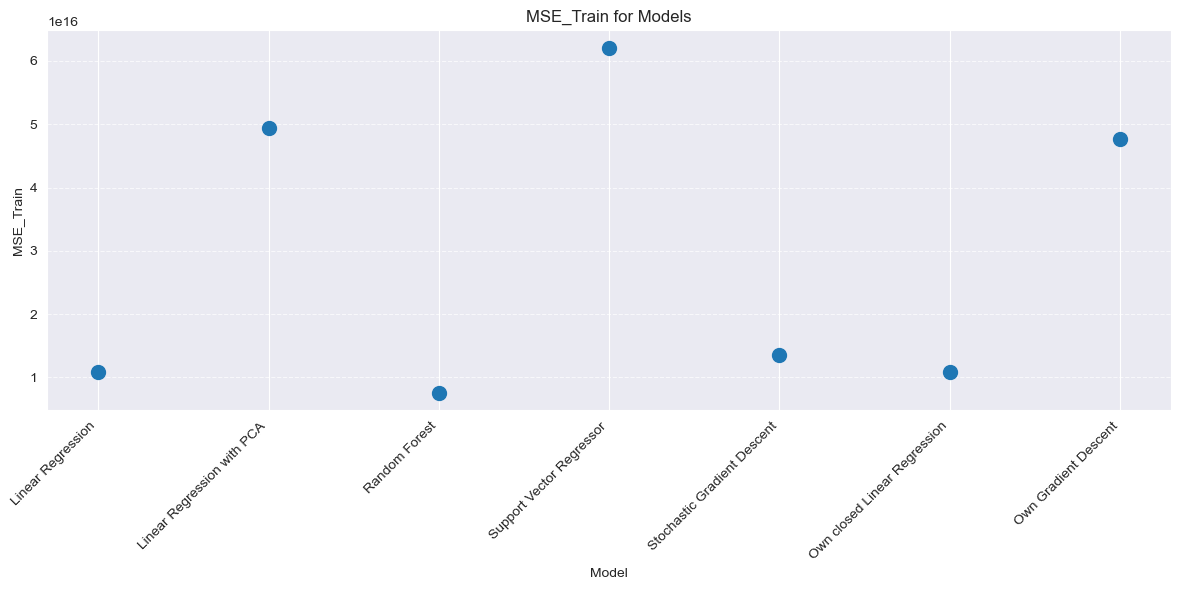

In [159]:
plot_metric_from_csv('estimates/estimated_data.csv','MSE_Train')

In [160]:
results = pd.read_csv('estimates/estimated_data.csv')
results.head(10)

,Model,MSE_Train,R2_Train,MSE_Test,R2_Test
0,Linear Regression,1.083752e+16,0.803217,6.533906e+16,-0.087189
1,Linear Regression with PCA,4.947365e+16,0.101681,5.677966e+16,0.055232
2,Random Forest,7.528704e+15,0.863297,5.589462e+16,0.069958
3,Support Vector Regressor,6.210356e+16,-0.127647,6.768609e+16,-0.126242
4,Stochastic Gradient Descent,1.354717e+16,0.754017,5.519307e+16,0.081632
5,Own closed Linear Regression,1.083752e+16,0.803217,6.534053e+16,-0.087214
6,Own Gradient Descent,4.771983e+16,0.133526,5.513667e+16,0.082570


### Takeaways:
1. Using PCA significantly worsens the results.
2. For our problem - best results come from regressions.
3. SVR just doesn't work for this dataset - too much variety.

# 3 - PyTorch implementation

### Data prep-up

Now, we will try to implement Linear Regression using PyTorch library

In [161]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

First - device selection.

In [162]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device used:", device)
print(torch.__version__)

Device used: cpu
2.5.1


Then conversion.

In [163]:
X_tensor = torch.tensor(X_train_proc, dtype=torch.float32) # we use processed data (after one-hot and normalized)
y_tensor = torch.tensor(y_train.values.reshape(-1, 1), dtype=torch.float32) # reshape, because we need it as a column

Now some we define data structures that will help us with batching and etc.

In [164]:
dataset = TensorDataset(X_tensor, y_tensor)
batch_size = 128
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, pin_memory=True) # shuffle lets us reuse data during training


The actual model looks like this.

In [165]:
class LinearRegressionModel(nn.Module): # extends nn.Module
    def __init__(self, input_dim):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, 1) #  defines the linear part - with input features and only 1 output feature - Streams

    def forward(self, x): # defines how to compute inputted data
        return self.linear(x)


The good thing is that PyTorch automatically creates wage matrix and adds bias.

In [166]:
input_dim = X_train_proc.shape[1] # number of features
model = LinearRegressionModel(input_dim)

criterion = nn.MSELoss() # criteria - MSE
optimizer = optim.SGD(model.parameters(), lr=0.01) # Optimize using Stochastic Gradient Descent

Now it's time for the essence - training function.

In [167]:
def train_model(model, train_loader, criterion, optimizer, device, epochs=10):
    """
    Trains PyTorch model with PyTorch DataLoader, criterion, and optimizer using device in number of epochs.
    :param model: PyTorch model
    :param train_loader: PyTorch DataLoader
    :param criterion: Criterion with loss function
    :param optimizer: Optimizer ex. torch.optim.SGD
    :param device: Cuda or Cpu
    :param epochs: How many epochs to train model with
    :return: Nothing
    """
    model.to(device)
    model.train() # sets the internal flag to train mode

    for epoch in range(epochs):
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader: # gets already made batches with shuffle true - same data might be reused
            X_batch, y_batch = X_batch.to(device), y_batch.to(device) # moves to the same device as model

            optimizer.zero_grad() # resets the gradient - as we use completely different batch every time
            outputs = model(X_batch) # estimates
            loss = criterion(outputs, y_batch) # results from loss function
            loss.backward() # calculates gradients for every parameter
            optimizer.step() # actualizes wages

            epoch_loss += loss.item() * X_batch.size(0)

        avg_loss = epoch_loss / len(train_loader.dataset)
        print(f"{device} : Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")


### Training

Now we can see how much time is needed to train our model.

In [168]:
# for CPU
start_time = time.time()
train_model(model, train_loader, criterion, optimizer, 'cpu', epochs=10)
elapsed_time_cpu = time.time() - start_time

# for GPU
start_time = time.time()
train_model(model, train_loader, criterion, optimizer, device, epochs=10)
elapsed_time = time.time() - start_time

print(f"Training time with GPU: {elapsed_time:.2f} s | CPU time: {elapsed_time_cpu:.2f} s")


cpu : Epoch [1/10], Loss: 62708437949060672.0000
cpu : Epoch [2/10], Loss: 54427411458531432.0000
cpu : Epoch [3/10], Loss: 52901888221872224.0000
cpu : Epoch [4/10], Loss: 52545723060140728.0000
cpu : Epoch [5/10], Loss: 52395633041652120.0000
cpu : Epoch [6/10], Loss: 52287125497566800.0000
cpu : Epoch [7/10], Loss: 52200471124545896.0000
cpu : Epoch [8/10], Loss: 52127898204857968.0000
cpu : Epoch [9/10], Loss: 52067800493241208.0000
cpu : Epoch [10/10], Loss: 52000874640911224.0000
cpu : Epoch [1/10], Loss: 51940065141894104.0000
cpu : Epoch [2/10], Loss: 51912387826704408.0000
cpu : Epoch [3/10], Loss: 51870179837443936.0000
cpu : Epoch [4/10], Loss: 51817813167190096.0000
cpu : Epoch [5/10], Loss: 51752217539165088.0000
cpu : Epoch [6/10], Loss: 51715470396096120.0000
cpu : Epoch [7/10], Loss: 51681891079302984.0000
cpu : Epoch [8/10], Loss: 51653387878582224.0000
cpu : Epoch [9/10], Loss: 51598509718738104.0000
cpu : Epoch [10/10], Loss: 51569484261509952.0000
Training time with

### Results

As we can see - it is trained in relatively short time (thanks to GPU usage). Results may now be calculated.

In [169]:
model.eval()

with torch.no_grad():
    X_test_tensor = torch.tensor(X_test_proc, dtype=torch.float32).to(device)
    X_train_tensor = torch.tensor(X_train_proc, dtype=torch.float32).to(device)
    predictions = model(X_test_tensor)
    test_predictions = predictions.cpu().numpy()
    predictions = model(X_train_tensor)
    train_predictions = predictions.cpu().numpy()

test_res = getResult(test_predictions, y_test)
train_res = getResult(train_predictions, y_train)

save_model_results("PyTorch Linear Regression", train_res, test_res)
print(f"PyTorch Linear Regression | MSE: {test_res[0]:,.0f} | R²: {test_res[1]:.4f}")

Saved to estimates\estimated_data.csv
PyTorch Linear Regression | MSE: 56,885,336,958,600,976 | R²: 0.0535


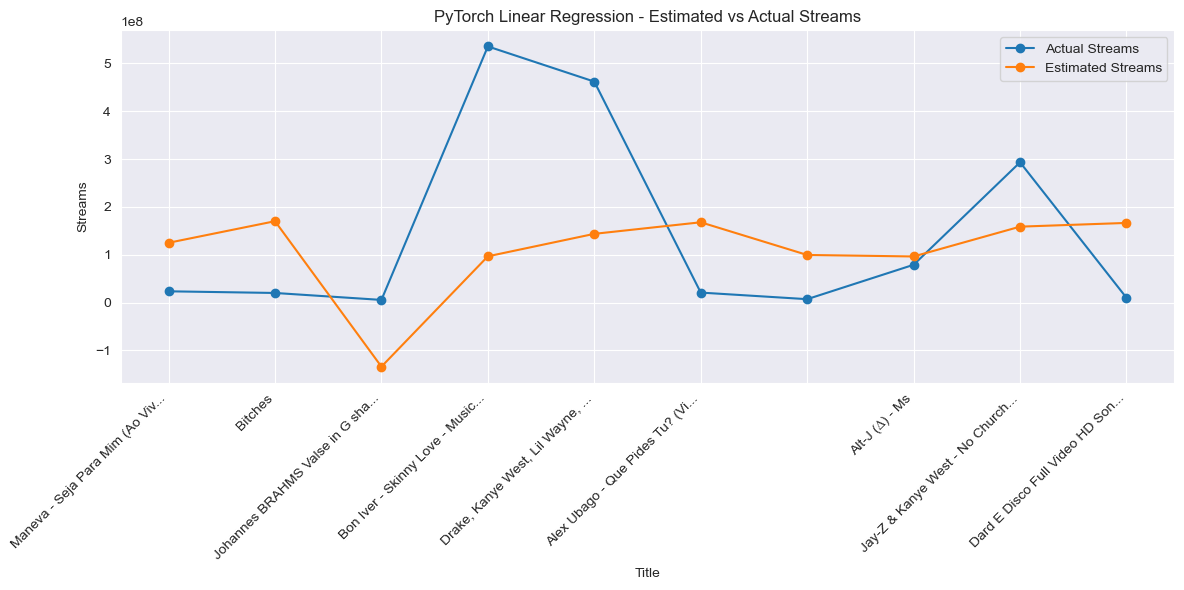

In [170]:
draw_chart(test_predictions, "PyTorch Linear Regression")

# 4. End Results

Finally, we can see how everything did and which model turned out to be the best.

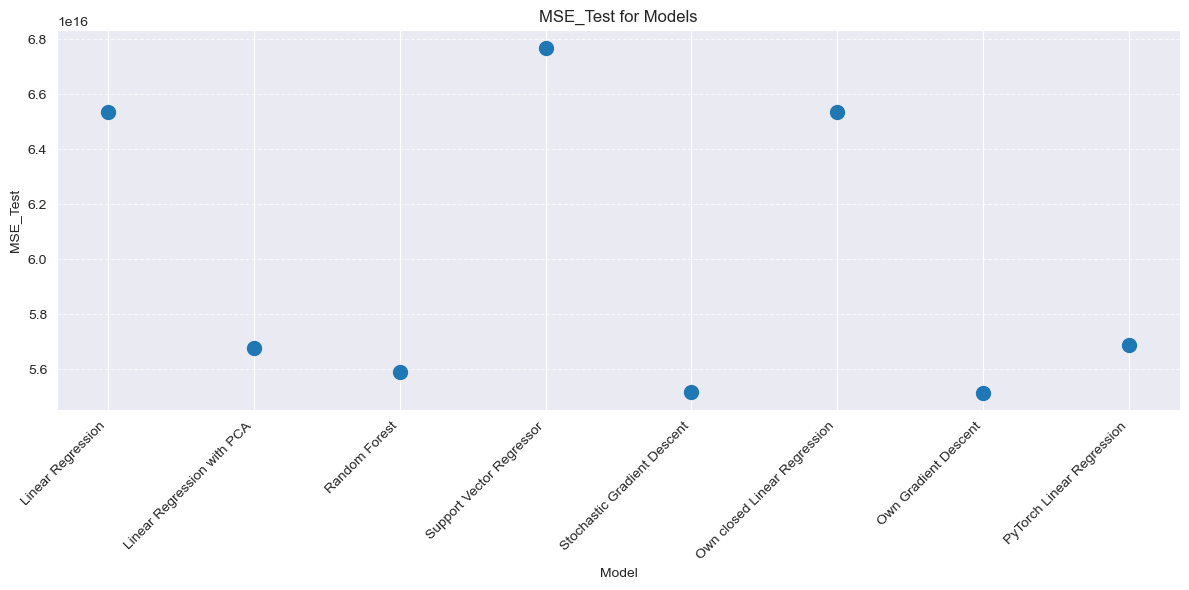

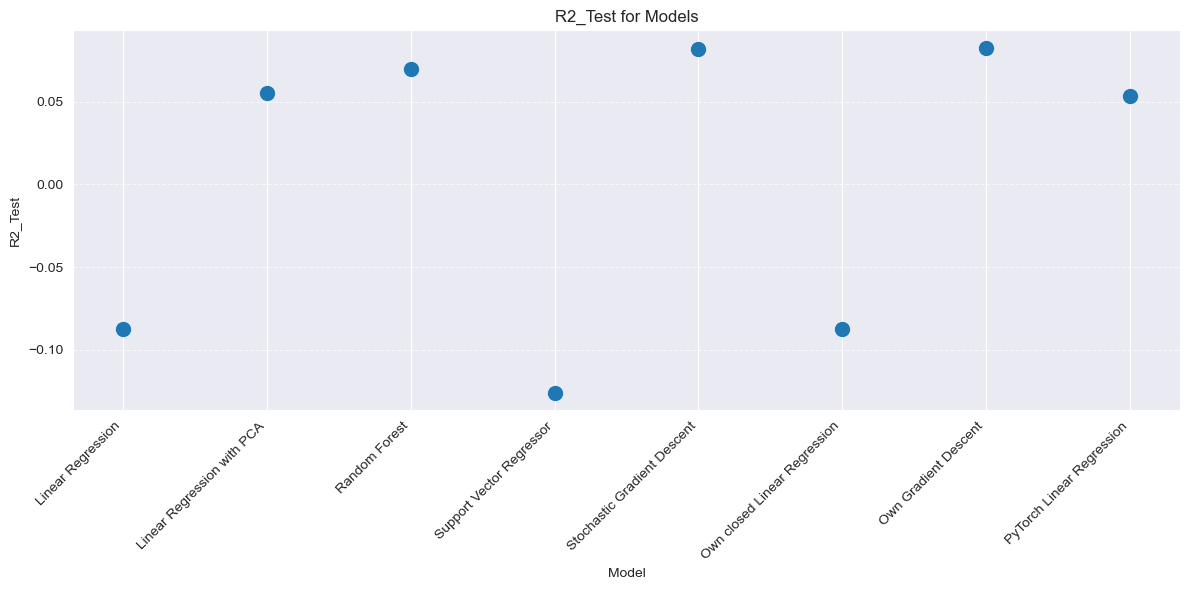

In [171]:
plot_metric_from_csv('estimates/estimated_data.csv', 'MSE_Test')
plot_metric_from_csv('estimates/estimated_data.csv', 'R2_Test')

In [172]:
results = pd.read_csv('estimates/estimated_data.csv')
results.head(10)

,Model,MSE_Train,R2_Train,MSE_Test,R2_Test
0,Linear Regression,1.083752e+16,0.803217,6.533906e+16,-0.087189
1,Linear Regression with PCA,4.947365e+16,0.101681,5.677966e+16,0.055232
2,Random Forest,7.528704e+15,0.863297,5.589462e+16,0.069958
3,Support Vector Regressor,6.210356e+16,-0.127647,6.768609e+16,-0.126242
4,Stochastic Gradient Descent,1.354717e+16,0.754017,5.519307e+16,0.081632
5,Own closed Linear Regression,1.083752e+16,0.803217,6.534053e+16,-0.087214
6,Own Gradient Descent,4.771983e+16,0.133526,5.513667e+16,0.082570
7,PyTorch Linear Regression,5.145598e+16,0.065687,5.688534e+16,0.053474


## Segment Summary

Some basic comparison between different models has been done - to be honest, these are simplest approaches, so to really make a model that can somewhat accurately predict how popular will be your song - we would need much more accurate approach and a lot of computational power.

In the end, after testing this on variety of different seeds, there is not really a clear winner. The best models seem to be:
1. Standard Linear Regression - simple to understand and fine-tune and surprisingly gives very good results.
2. Linear Regression with PCA - works much faster than regular, but gives a bit less accurate results.
3. Random Forest - very dependent on the training set - results vary depending on which split seed is set.
4. SVR - terrible in this case - too many important outliers that cannot be omitted.
5. Stochastic Gradient Descent - surprisingly consistently worse than own implementation (especially when trained on large dataset), plus for extensive fine-tuning possibilities.
6. Own closed Linear Regression - extremely fast (no iteration and PCA), similar results to standard from sklearn.
7. Own Gradient Descent - fast and reliable with adjustable batch size - one of the pros is that time it takes to be trained can be controlled (through iteration limit).
8. PyTorch Linear Regression - fastest (thanks to GPU) and pretty reliable with results - industry standard.


# Optimisation and stability testing

In this part we will try and optimise our models using various techniques as well as check their stability.

### 1. Stability check with K-Fold
First, let's check stability of our own closed linear regression using KFolds. This is a very simple step that tells us whether the model is susceptible to different data splits.

Now let's import the KFold module.

In [173]:
from sklearn.model_selection import KFold

In [174]:
kf = KFold(n_splits=3, shuffle=True, random_state=42)
scores = []
wages = []
i=0

for train_idx, test_idx in kf.split(X):
    X_train_fold, X_test_fold = preprocessor_PCA.fit_transform(X.iloc[train_idx]), preprocessor_PCA.transform(X.iloc[test_idx])
    y_train_fold, y_test_fold = Y.iloc[train_idx], Y.iloc[test_idx]

    # add bias
    X_train_b_fold = np.hstack([np.ones((X_train_fold.shape[0], 1)), X_train_fold])
    X_test_b_fold = np.hstack([np.ones((X_test_fold.shape[0], 1)), X_test_fold])

    # train using own closed linear regression
    w = closed_linear_regression(X_train_b_fold, y_train_fold)

    # predict
    y_pred = X_test_b_fold @ w

    # results
    result = getResult(y_test_fold, y_pred)
    scores.append(result)
    wages.append(w)
    #draw_chart(y_pred, f"Fold: {i}", seed=10, true_set=y_test_fold)
    i = i+1

print("MSE and R2 for every fold:", scores)
mse_list = [record[0] for record in scores]
for i, result in enumerate(mse_list):
    print(f"{i} | MSE: {result:,.0f}")
    save_model_results(f"{i}", None, (result,0), 'Kfold_result.csv')
print("Mean MSE:", np.mean(mse_list))


MSE and R2 for every fold: [(5.77330205513002e+16, -19.515955002163498), (5.677093870093228e+16, -15.220121325446414), (5.434493651828839e+16, -14.909382417616063)]
0 | MSE: 57,733,020,551,300,200
Saved to estimates\Kfold_result.csv
1 | MSE: 56,770,938,700,932,280
Saved to estimates\Kfold_result.csv
2 | MSE: 54,344,936,518,288,392
Saved to estimates\Kfold_result.csv
Mean MSE: 5.628296525684029e+16


As we can see - results are pretty close to one another. This means our model is fairly stable (even considering our data packed with outliers).
Let's check best split found by these folds (just for measure).

MSE: 60396426072763096.0000 | R2: -0.0049


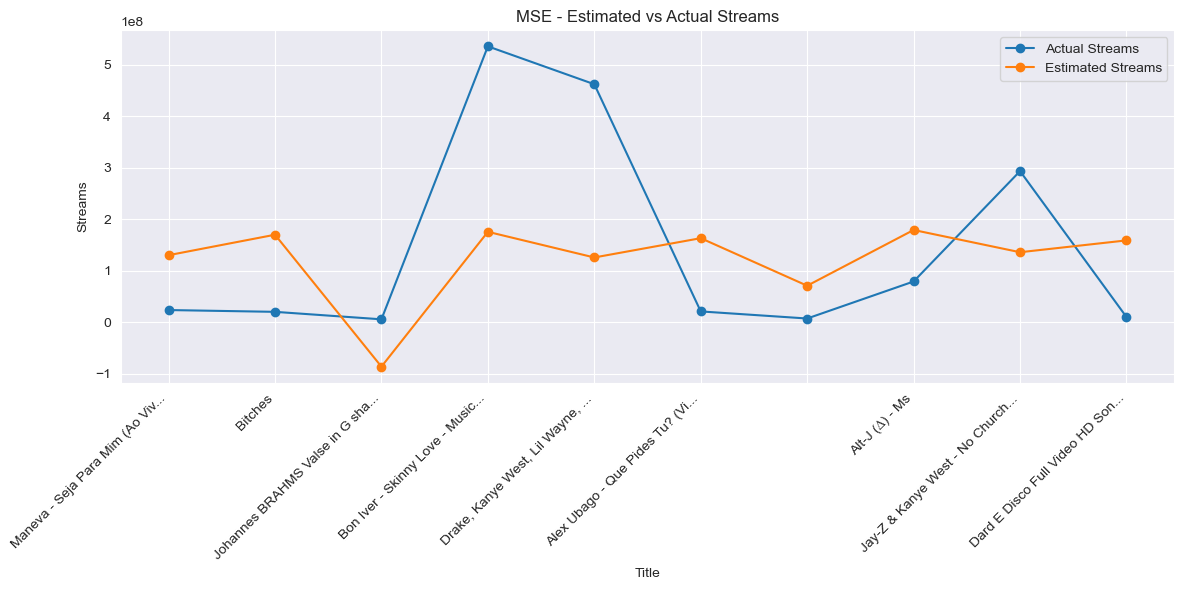

In [175]:
best_result = mse_list.index(min(mse_list))
best_wage = wages[best_result]
best_pred = X_test_b_pca @ best_wage
result = getResult(best_pred, y_test)
print(f"MSE: {result[0]:.4f} | R2: {result[1]:.4f}")
draw_chart(best_pred, "MSE")

### 2. Overfitting test with PolynomialFeatures

Overfitting is a occurrence that signals model's wrong training behaviour - model instead of learning general rules and correlations, instead focuses too much on training data itself, finding correlations that occur only in training data and not in the actual problems. This may happen to number of reasons - most commonly due to having over-correlated training data.

To simulate this we can ise PolynomialFeatures from sklearn that will enlarge our training data with random correlations of it (ex. x1*x2, x1+x2..).

In [176]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=True)
poly_scaler = StandardScaler()

X_train_poly = (poly.fit_transform(X_train_proc_pca)) # to avoid learning curve being chaotic
X_test_poly = (poly.transform(X_test_proc_pca))

After transforming we have much more correlated data. Let's see if overfitting wil occur.

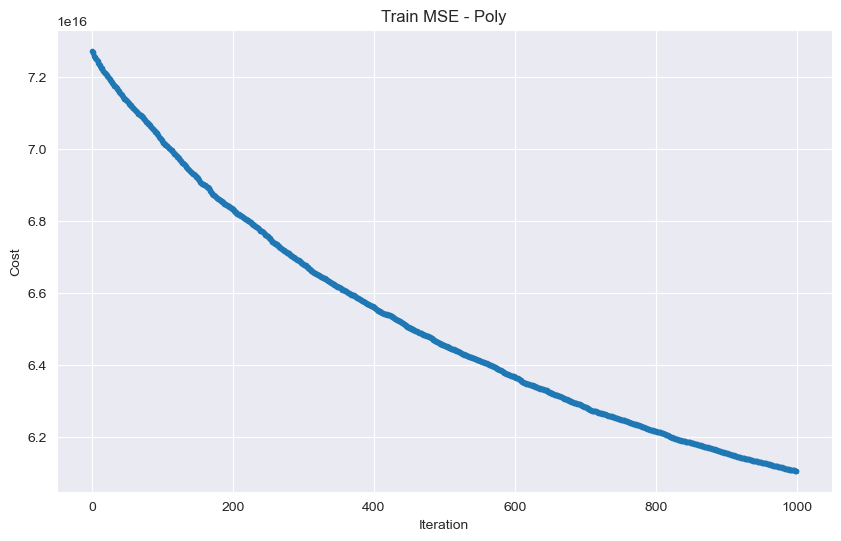

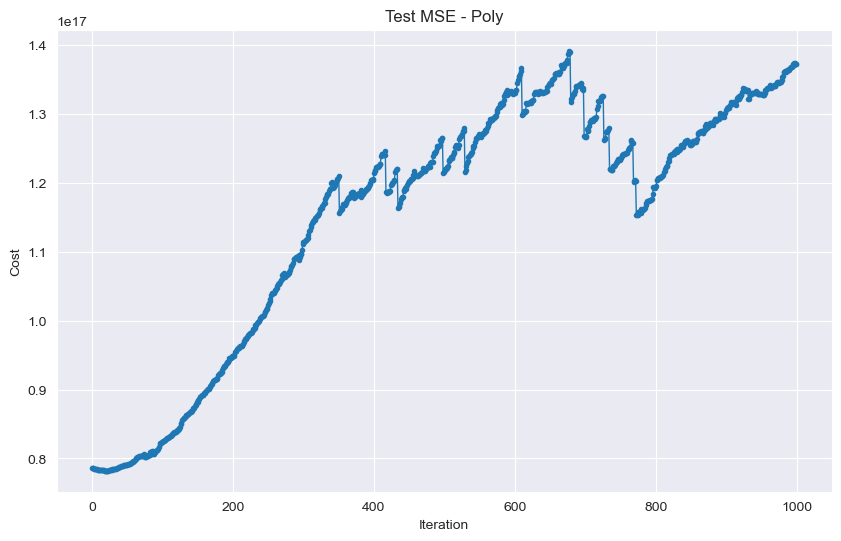

In [177]:
w_grad_poly, cost_history_poly, cost_history_test_poly = gradient_descent(X_train_poly, y_train, np.random.randn(X_train_poly.shape[1]), 0.0001, iterations=1000, X_test=X_test_poly, y_test=y_test) # initialize w with random values

draw_fitting_chart(cost_history_poly, "Train MSE - Poly")
draw_fitting_chart(cost_history_test_poly, "Test MSE - Poly")

Now we can see this learning curve is very over-fitted - cost for training set reduces while for test data gets bigger.

### 3. Regularisation with Lasso and Ridge method

One way to reduce overfitting is to use regularisation. This is a simple element which is added to cost function that punishes big wages values.

- Ridge regularisation - causes reduction in outlier wage's value. (sum of the squared wage's values)
- Lasso regularisation - may cause extreme reduction in outlier wage's value. (sum of the absoulute wage's values)

This is our gradient descent but written with regularisation.

In [178]:
def gradient_descent_reg(X, y, w_init, learning_rate=0.01, *, iterations=1000, epsilon=None, batch_size=32, X_test=None, y_test=None, regularization=None, lambda_=0.1):
    n = len(y)
    w = w_init.copy()
    cost_history = []
    cost_history_test = []

    for i in range(iterations):
        # Random mini-batch
        batch_indices = np.random.choice(n, size=batch_size, replace=False)
        X_batch = X[batch_indices]
        y_batch = y[batch_indices]

        predictions = X_batch @ w
        error = predictions - y_batch

        # Base gradient
        gradient = (1 / batch_size) * (X_batch.T @ error)

        # Apply regularization to gradient
        if regularization == 'ridge':  # Ridge
            gradient += lambda_ * w             # derivative from it's segment in cost function
        elif regularization == 'lasso':  # Lasso
            gradient += lambda_ * np.sign(w)

        # Update weights
        w = w - learning_rate * gradient

        full_predictions = X @ w
        cost = mean_squared_error(y, full_predictions)

        # Add regularization term to cost
        if regularization == 'ridge':
            cost += lambda_ * np.sum(w**2)
        elif regularization == 'lasso':
            cost += lambda_ * np.sum(np.abs(w))

        cost_history.append(cost)

        if X_test is not None and y_test is not None:
            test_predictions = X_test @ w
            cost_test = mean_squared_error(y_test, test_predictions)

            #if regularization == 'ridge':
            #    cost_test += lambda_ * np.sum(w**2)
            #elif regularization == 'lasso':
            #    cost_test += lambda_ * np.sum(np.abs(w))

            cost_history_test.append(cost_test)

        # Early stopping
        if epsilon is not None and i > 0:
            if abs(cost_history[-2] - cost_history[-1]) < epsilon:
                print(f"Stopped early at iteration {i} (change < epsilon={epsilon})")
                break

    return w, cost_history, cost_history_test

First, let's see if this enhances results.

In [179]:

w_grad_reg, cost_history_reg, cost_history_test_reg = gradient_descent_reg(X_train_b, y_train, np.zeros(X_train_b.shape[1]), iterations=5000, X_test=X_test_b, y_test=y_test, regularization='ridge', lambda_=1) # initialize w with random values

w_grad_reg_l, cost_history_reg_l, cost_history_test_reg_l = gradient_descent_reg(X_train_b, y_train, np.zeros(X_train_b.shape[1]), iterations=5000, X_test=X_test_b, y_test=y_test, regularization='lasso', lambda_=1) # initialize w with random values

Quick peek to learning curve.

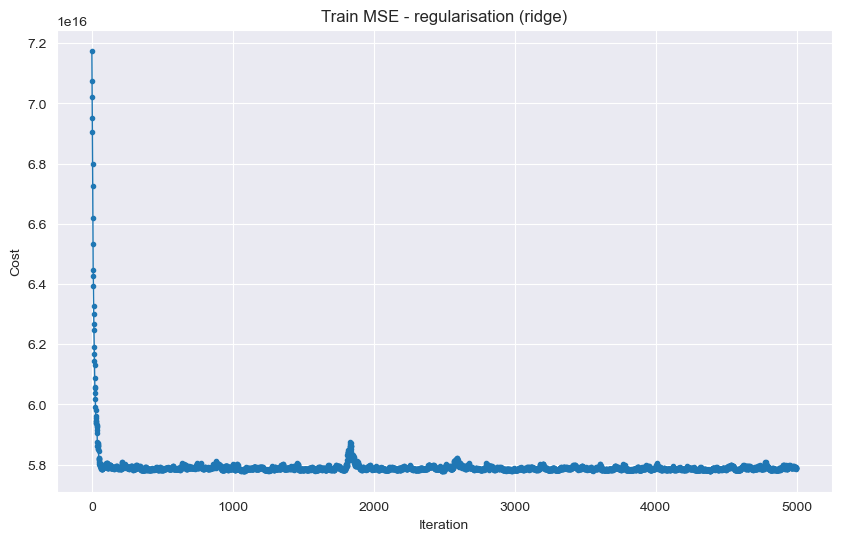

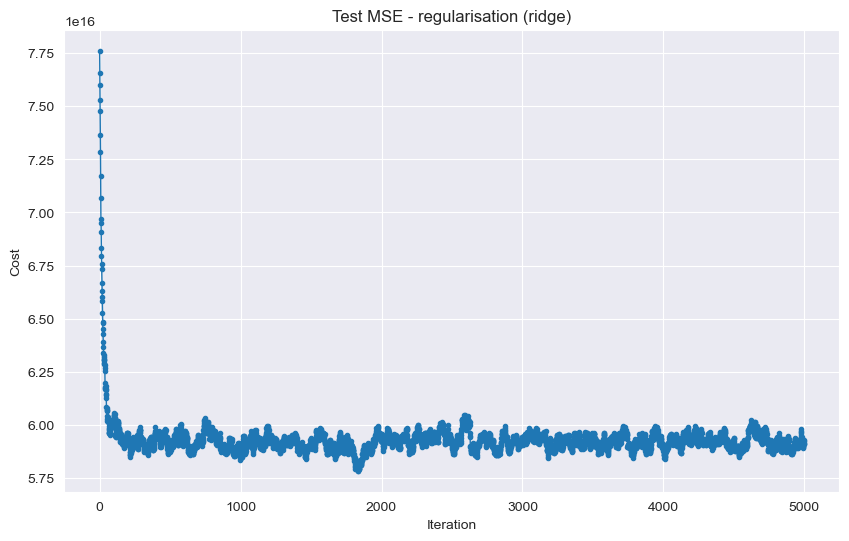

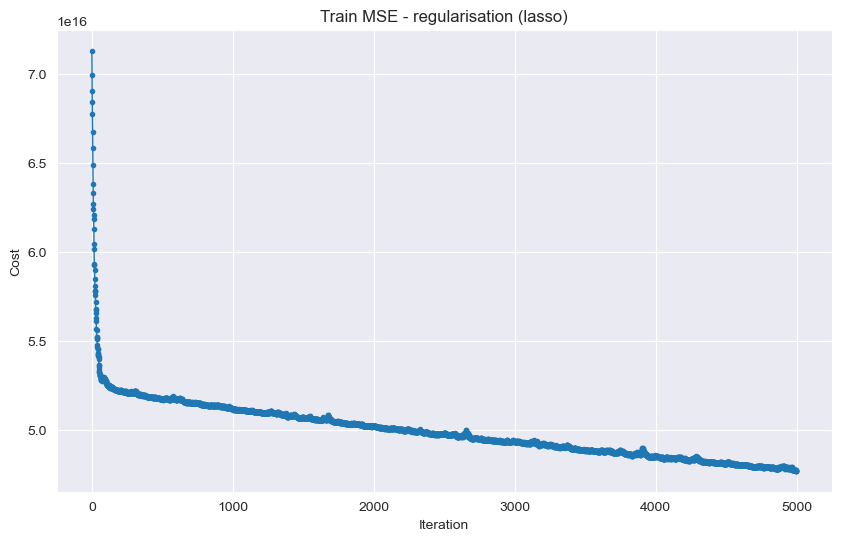

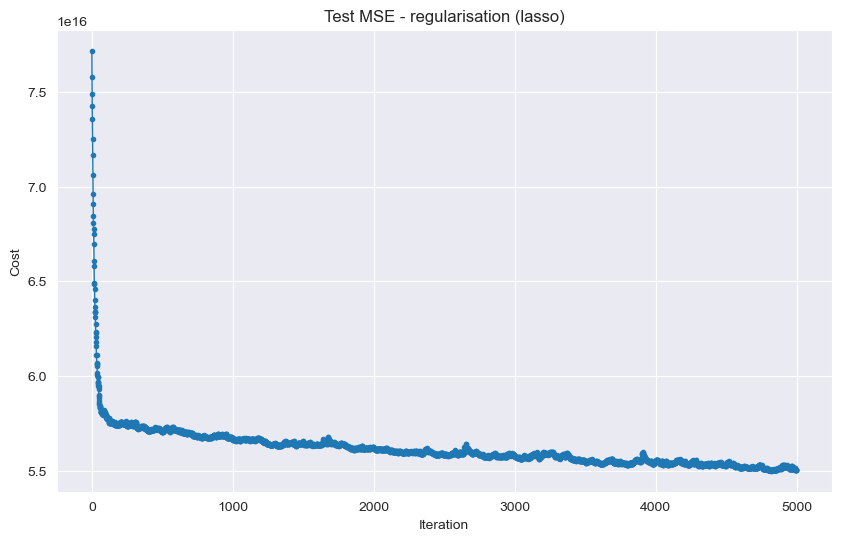

In [180]:
draw_fitting_chart(cost_history_reg, "Train MSE - regularisation (ridge)")
draw_fitting_chart(cost_history_test_reg, "Test MSE - regularisation (ridge)")
draw_fitting_chart(cost_history_reg_l, "Train MSE - regularisation (lasso)")
draw_fitting_chart(cost_history_test_reg_l, "Test MSE - regularisation (lasso)")

Let's see wage's difference.

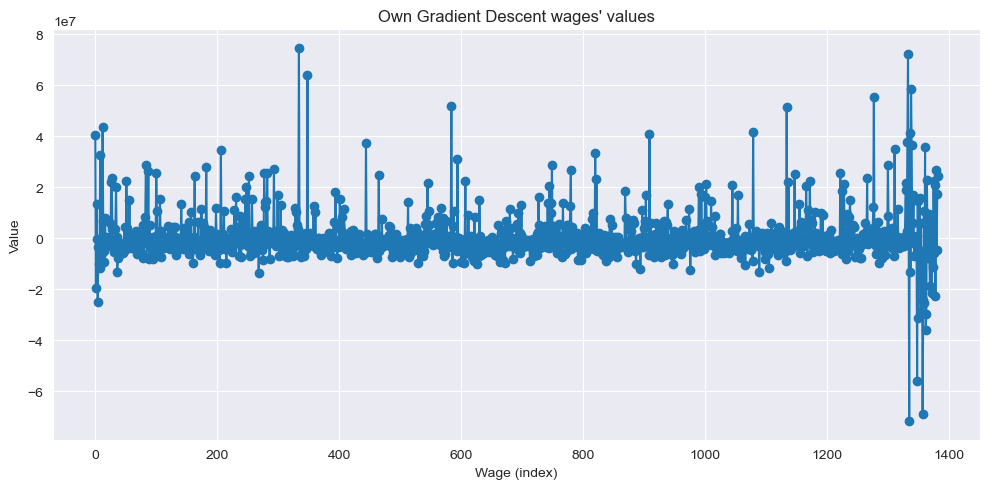

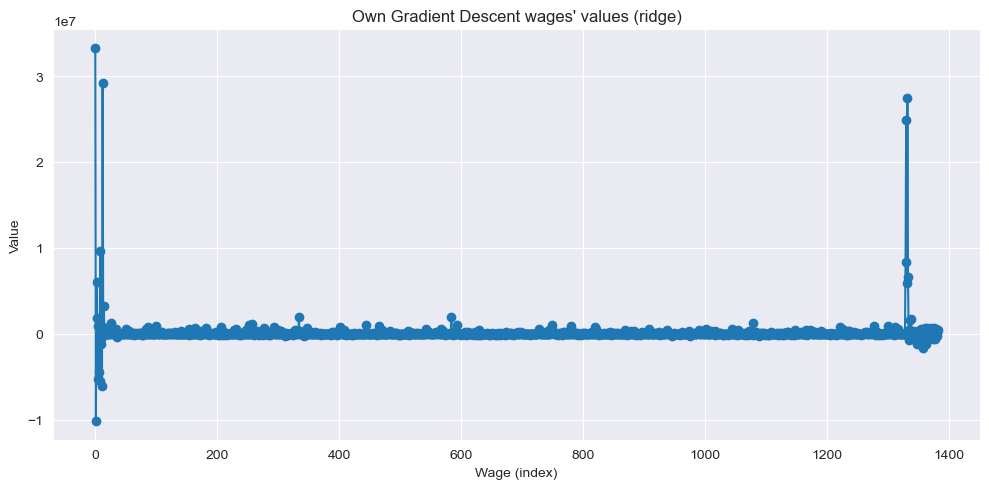

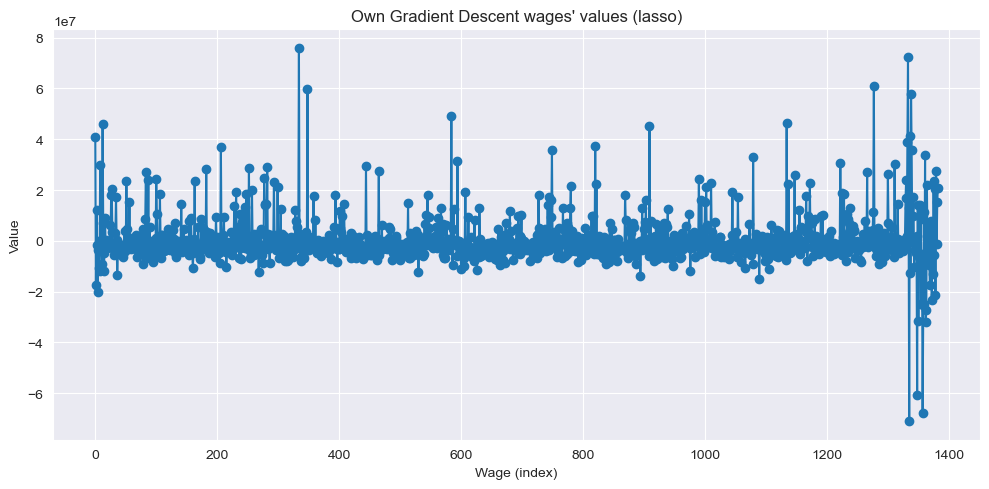

In [181]:
def plot_weights(weights, name="Wage's values", save=True):
    plt.figure(figsize=(10, 5))
    plt.plot(np.arange(len(weights)), weights, marker='o')
    plt.xlabel("Wage (index)")
    plt.ylabel("Value")
    plt.title(name)
    plt.grid(True)
    plt.tight_layout()
    if save:
        os.makedirs('estimates/wage_charts', exist_ok=True)
        plt.savefig(f'estimates/wage_charts/{name}_wage_chart.png')
    plt.show()

plot_weights(w_grad, "Own Gradient Descent wages' values")
plot_weights(w_grad_reg, "Own Gradient Descent wages' values (ridge)")
plot_weights(w_grad_reg_l, "Own Gradient Descent wages' values (lasso)")

Values are similar with outliers a bit dampened. Let us see the results.

Own Gradient Descent with Regularisation (ridge) | MSE: 59,294,461,712,611,368 | R²: 0.0134
Saved to estimates\estimated_data.csv


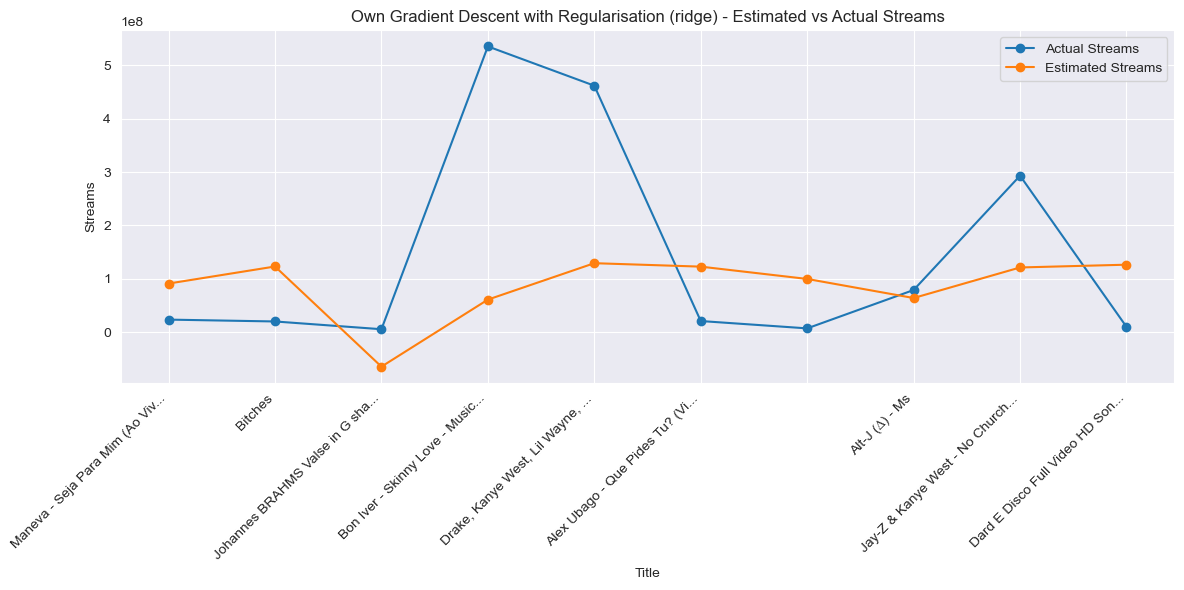

Own Gradient Descent with Regularisation (lasso) | MSE: 55,036,349,631,585,152 | R²: 0.0842
Saved to estimates\estimated_data.csv


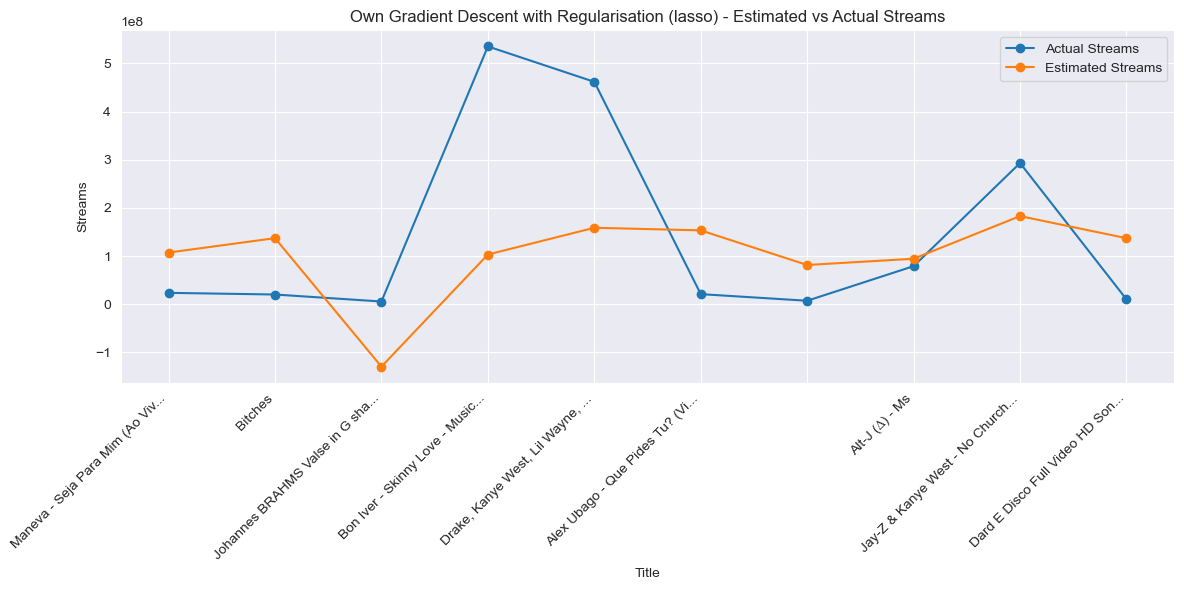

In [182]:
for name, pred in [('Own Gradient Descent with Regularisation (ridge)', w_grad_reg), ('Own Gradient Descent with Regularisation (lasso)', w_grad_reg_l)]:
    y_pred_grad = X_test_b @ pred
    y_pred_train = X_train_b @ pred

    train_res = getResult(y_pred_train, y_train)
    test_res = getResult(y_pred_grad, y_test)

    print(f"{name} | MSE: {test_res[0]:,.0f} | R²: {test_res[1]:.4f}")
    save_model_results(f"{name}", train_res, test_res)
    draw_chart(y_pred_grad, f"{name}")

### Hyper-Parameters fine-tuning with GridSearch

Previously we set the parameters of the models based on 'default' or own imagination. This is fine for simplicity, but some models require certain parameters to work optimally. We will test it on three previously selected.
- Random Forest
- SGD
- SVR

This works fairly simple - its taking every combination of parameters and test them on number of folds (as we did in previous chapter) then gets the mean and chooses best one.

Let's first do this on Random Forest.

In [183]:
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(random_state=42)

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'max_features': [None, 'sqrt', 'log2']
}

grid_rf = GridSearchCV(rf, param_grid_rf, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_rf.fit(X_train_proc, y_train)

print("Best parameters RandomForest:", grid_rf.best_params_)
print("Best MSE:", grid_rf.best_score_ * -1)

Best parameters RandomForest: {'max_depth': None, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 100}
Best MSE: 5.045324264794445e+16


And now the same goes for SGD Regressor.

In [184]:
sgd = SGDRegressor(random_state=42, max_iter=1000, tol=1e-3)

param_grid_sgd = {
    'alpha': [0.0001, 0.001, 0.01, 0.1],  # regularisation
    'penalty': ['l2', 'l1', 'elasticnet'],
    'learning_rate': ['constant', 'optimal', 'invscaling', 'adaptive'],
    'eta0': [0.001, 0.01, 0.1]  # learning rate
}

grid_sgd = GridSearchCV(sgd, param_grid_sgd, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_sgd.fit(X_train_proc, y_train)

print("Best parameters SGDRegressor:", grid_sgd.best_params_)
print("Best MSE:", grid_sgd.best_score_ * -1)

Best parameters SGDRegressor: {'alpha': 0.001, 'eta0': 0.01, 'learning_rate': 'invscaling', 'penalty': 'l2'}
Best MSE: 4.9176427149137304e+16


C:\Users\Michal\miniconda3\envs\msid_lab\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


And the same for SVR - which was the worst on default settings.

In [185]:
svr = SVR()

param_grid_svr = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': [0.1, 1, 10],
    'epsilon': [0.01, 0.1, 1],
    'gamma': ['scale', 'auto']
}

grid_svr = GridSearchCV(svr, param_grid_svr, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_svr.fit(X_train_proc, y_train)

print("Best parameters SVR:", grid_svr.best_params_)
print("Best MSE:", grid_svr.best_score_ * -1)

Best parameters SVR: {'C': 10, 'epsilon': 0.01, 'gamma': 'scale', 'kernel': 'poly'}
Best MSE: 6.210654311693578e+16


Now for the results.

SGD Regressor tuned | MSE: 50,641,771,457,551,552 | R²: 0.1574
Saved to estimates\estimated_data.csv


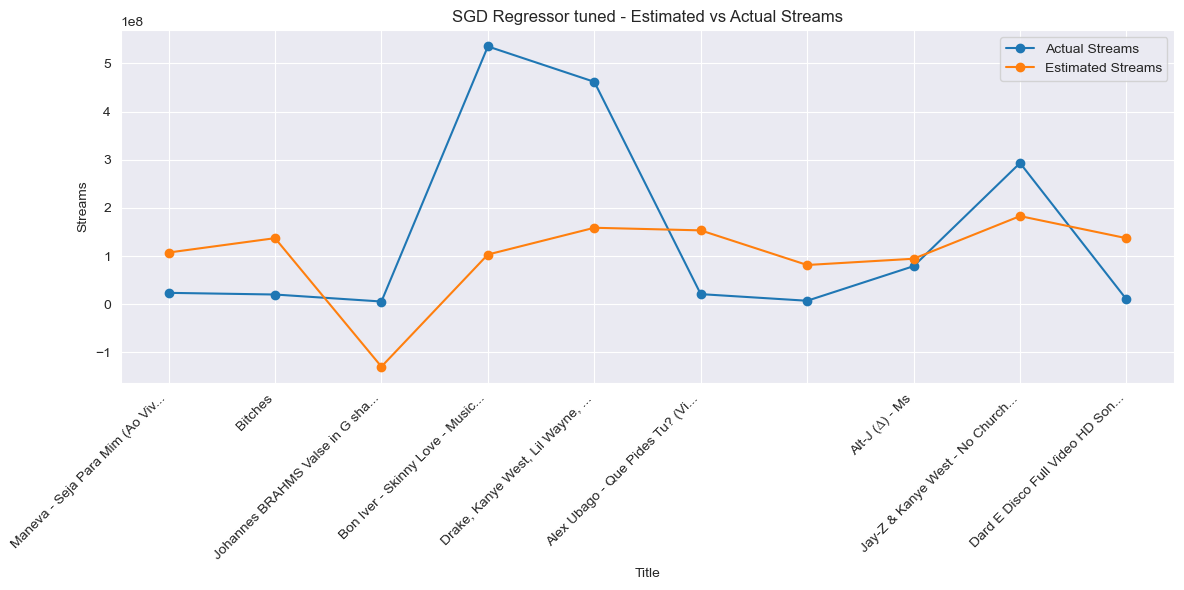

Random Forest tuned | MSE: 53,508,347,727,513,168 | R²: 0.1097
Saved to estimates\estimated_data.csv


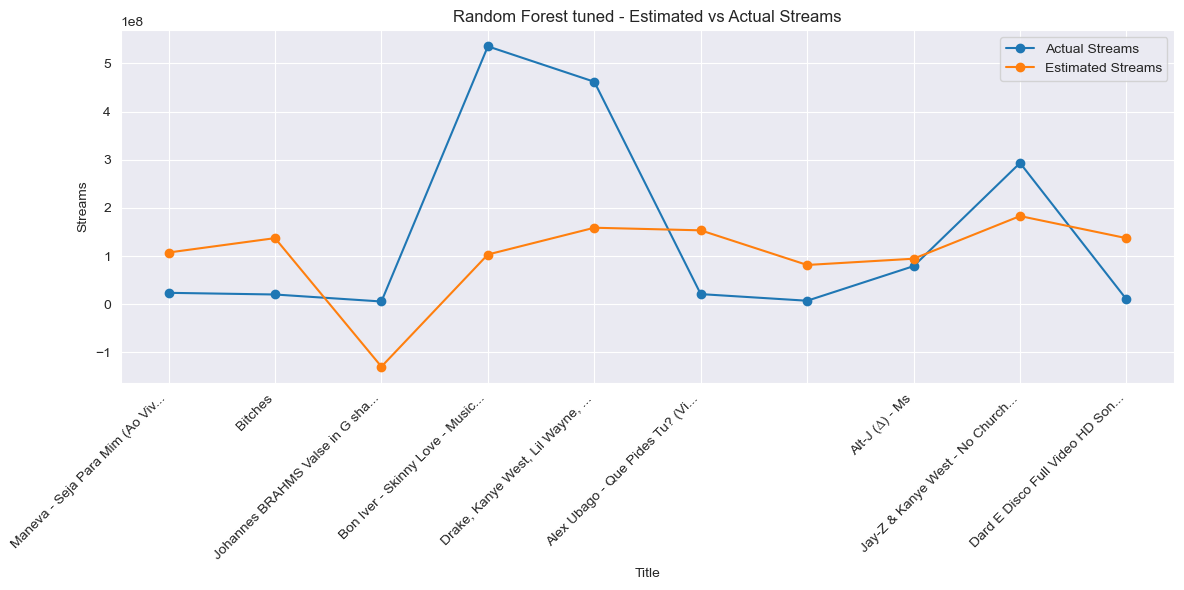

SVR tuned | MSE: 67,686,078,117,496,024 | R²: -0.1262
Saved to estimates\estimated_data.csv


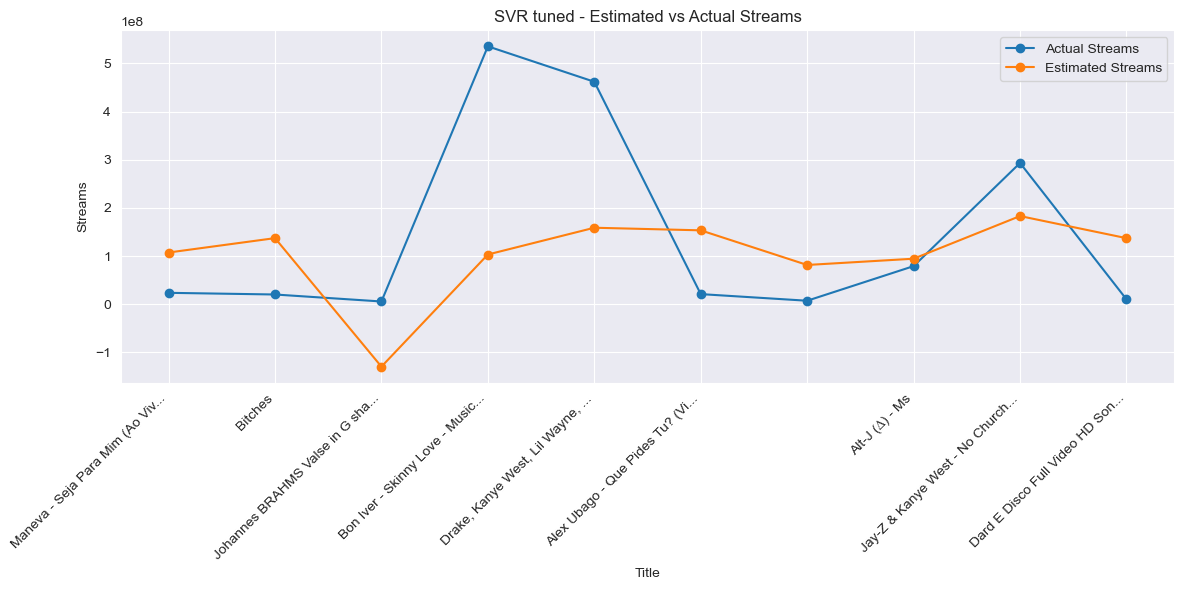

In [186]:
best_sgd = grid_sgd.best_estimator_
best_rf = grid_rf.best_estimator_
best_svr = grid_svr.best_estimator_

for pair in [('SGD Regressor tuned',best_sgd),('Random Forest tuned', best_rf), ('SVR tuned',best_svr)]:
    name, model = pair
    y_pred_grid = model.predict(X_test_proc)
    y_pred_train = model.predict(X_train_proc)

    train_res = getResult(y_pred_train, y_train)
    test_res = getResult(y_pred_grid, y_test)

    print(f"{name} | MSE: {test_res[0]:,.0f} | R²: {test_res[1]:.4f}")
    save_model_results(f"{name}", train_res, test_res)
    draw_chart(y_pred_grad, f"{name}")

### Ensemble testing

In this part we will try few of the most simple ensembling methods and then try and make a Mixture of Experts.

Ensemble methods are pretty straight-forward mechanisms that is used to resolve typical problems of a single model. They use different models to try and predict the best estimation and negate each's model shortcomings.

Firsty let's look at the simplest of them all - VotingRegressor. What it does is it's taking mean of all of the model's prediction and present it as a solution.

In [ ]:
from sklearn.ensemble import VotingRegressor

# models choice
base_models = [
    ('lr', LinearRegression()),
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('svr', SVR())
]

voting_reg = VotingRegressor(estimators = base_models)

voting_reg.fit(X_train_proc, y_train) # training

And for the results.

Voting Regressor | MSE: 53,876,041,349,653,584 | R²: 0.1035
Saved to estimates\estimated_data.csv


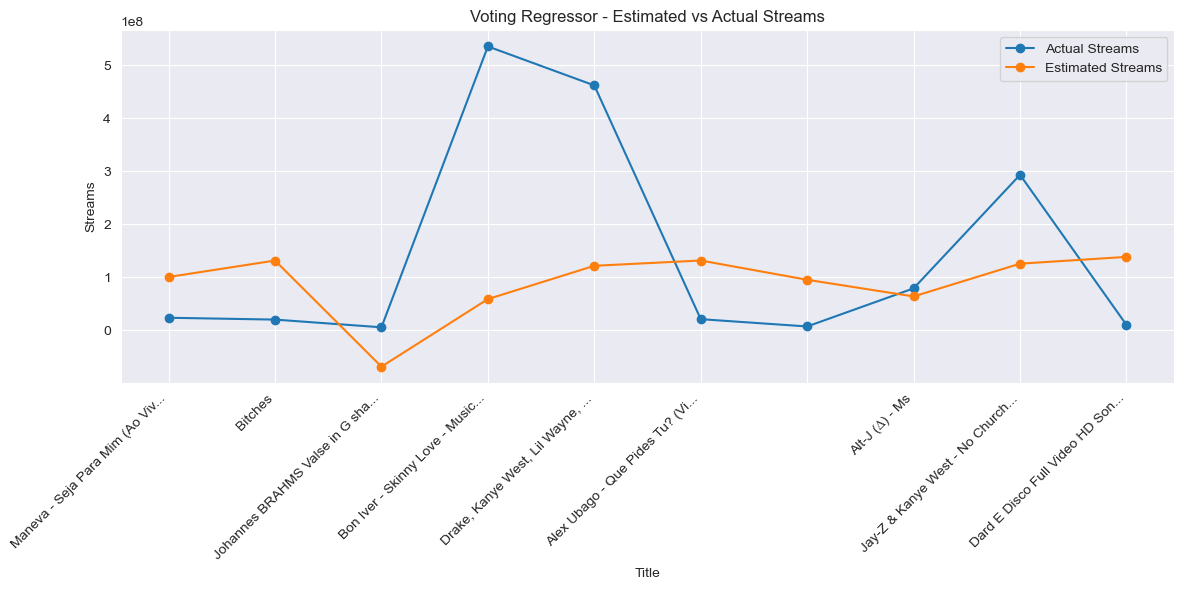

In [60]:
model = voting_reg
name = "Voting Regressor"

y_pred_grid = model.predict(X_test_proc)
y_pred_train = model.predict(X_train_proc)

train_res = getResult(y_pred_train, y_train)
test_res = getResult(y_pred_grid, y_test)

print(f"{name} | MSE: {test_res[0]:,.0f} | R²: {test_res[1]:.4f}")
save_model_results(f"{name}", train_res, test_res)
draw_chart(y_pred_grad, f"{name}")

Now let us go to StackingRegressor.

This is more advanced ensemble method that actually tries to learn strong side of each model included. It basically has a meta-model that is fed predictions from the models included and then learns in which case, which combination of predictions to use (ex. models learn tact if 1 model gives a high prediction and two other give a lower one, it will take the highest number and reduce it by 20% of the difference between highest and lowest).

In [61]:
from sklearn.ensemble import StackingRegressor

# Meta-model - we will use a simple LinearRegression
final_model = LinearRegression()

stacking_reg = StackingRegressor(
    estimators=base_models,
    final_estimator=final_model,
    passthrough=False,  # if True, meta-model gets original data as well
    cv=3,               # 3-fold cross-validation
    n_jobs=-1
)

stacking_reg.fit(X_train_proc, y_train) # training

StackingRegressor(cv=3,
                  estimators=[('lr', LinearRegression()),
                              ('rf', RandomForestRegressor(random_state=42)),
                              ('svr', SVR())],
                  final_estimator=LinearRegression(), n_jobs=-1)

And the results.

Stacking Regressor | MSE: 53,156,042,081,341,408 | R²: 0.1155
Saved to estimates\estimated_data.csv


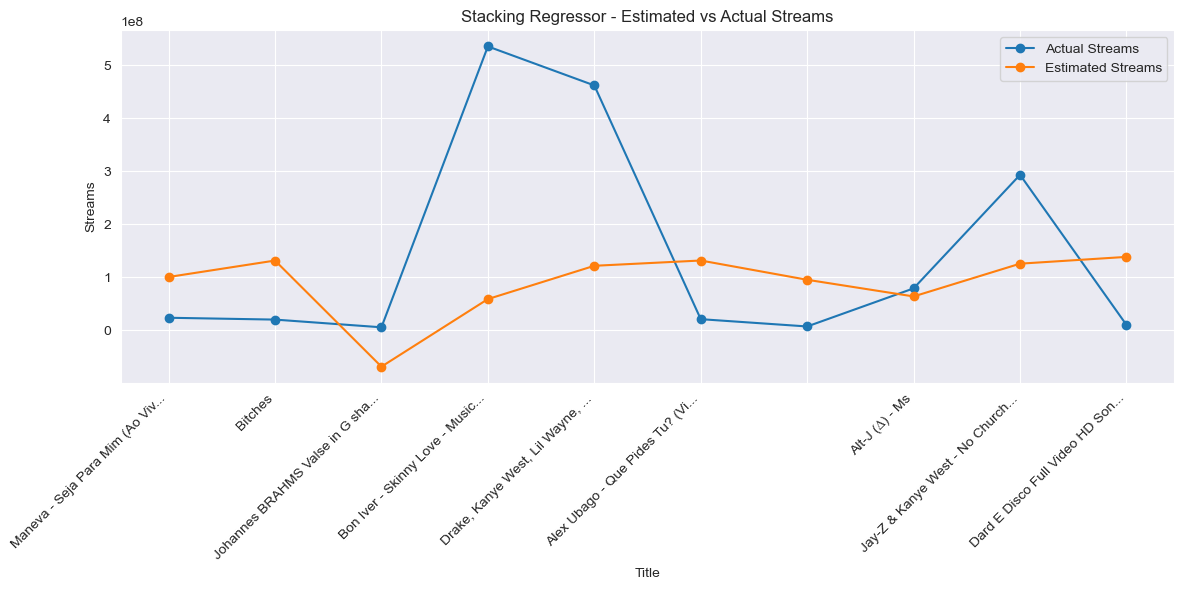

In [62]:
model = stacking_reg
name = "Stacking Regressor"

y_pred_grid = model.predict(X_test_proc)
y_pred_train = model.predict(X_train_proc)

train_res = getResult(y_pred_train, y_train)
test_res = getResult(y_pred_grid, y_test)

print(f"{name} | MSE: {test_res[0]:,.0f} | R²: {test_res[1]:.4f}")
save_model_results(f"{name}", train_res, test_res)
draw_chart(y_pred_grad, f"{name}")

##### Mixture of Experts

This is a interesting concept - basically we create an architecture in which there are many models (experts) and each one is specialised in different case of data. For every entry set of data, a 'gate' is present, which decides what experts to use and in which level (so basically an evolved ensembling mechanism).

This can be compared to real life scenarios like working in a team. If there is a task like creating a advertisement, we would like to hear mostly from PR departament and from Fund-raising and maybe a bit less from Engineering - so the final decision would be dependent in 50% on PR's choice, 30% on FR's and 20% on Engineering. Other, more technical tasks may require for example 80% dependency on Engineering side - and so on.

This approach is widely used in large models because:
- it's using the undying 'divide and conquer' tactic which can be beneficial,
- is highly scalable,
- training on different models can be done simultaneously.

In [63]:
from sklearn.base import BaseEstimator, RegressorMixin

class MixtureOfExperts(BaseEstimator, RegressorMixin):
    """
    Simple class dedicated to showcase Mixture of Experts method - fitting part done one by one not in parallel.
    """
    def __init__(self, experts, gating_model):
        """
        Default constructor.
        :param experts: models which will be trained separately.
        :param gating_model: 'gate' for expert selection.
        """
        self.experts = experts
        self.gating_model = gating_model

    def fit(self, X, y):
        # train each expert
        for expert in self.experts: # can be done simultaneously but here we go with basics
            expert.fit(X, y)

        # check which expert was the best for specific case
        preds = np.array([expert.predict(X) for expert in self.experts])  # shape: (n_experts, n_samples)

        # find the best expert using abs difference between prediction and actual value (we
        best_expert = np.argmin(np.abs(preds - y), axis=0) # return an array with values that indicate which expert was the best

        # make sure every expert is included at least once
        for i in range(len(self.experts)):
            if i not in np.unique(best_expert):
                X = np.vstack([X, X[0]])
                best_expert = np.append(best_expert, i) # adds a copy of 1st example and gives it to the expert

        # train gating model
        self.gating_model.fit(X, best_expert)
        return self

    def predict(self, X):
        # gate wages — shape (n_samples, n_experts)
        gating_probs = self.gating_model.predict_proba(X)
        expert_preds = np.array([expert.predict(X) for expert in self.experts])  # shape (n_experts, n_samples)

        # weighted sum of the wages and expert predictions
        final_pred = np.sum(gating_probs.T * expert_preds, axis=0)
        return final_pred

Ok so now we have everything ready - time to choose the gating model.

Here are the choices:
- MLPClassifier - neural network works well on big dataset with non-linear dependencies,
- LogisticRegression - works good when correlations are pretty linear,
- RandomForestClassifier - good with a big set of data with 'noise'.

We can test each one and see which is best.

In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

gating_models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "MLPClassifier": MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000, random_state=42),
    "RandomForestClassifier": RandomForestClassifier(n_estimators=100, random_state=42)
}

res = []
experts = [model for name, model in base_models]

for name, gating_model in gating_models.items():
    moe = MixtureOfExperts(experts=experts, gating_model=gating_model)
    moe.fit(X_train_proc, np.array(y_train))
    y_pred_moe = moe.predict(X_test_proc)
    y_pred_train = moe.predict(X_train_proc)
    train_res = getResult(y_pred_train, y_train)
    test_res = getResult(y_pred_moe, y_test)
    save_model_results(name, train_res, test_res, 'gating_model_comp.csv')
    res.append((name, test_res, train_res))


Saved to estimates\gating_model_comp.csv
Saved to estimates\gating_model_comp.csv
Saved to estimates\gating_model_comp.csv


Now we will see the results - which gating model was the best and we will add it  to other models' comparison.

Saved to estimates\estimated_data.csv


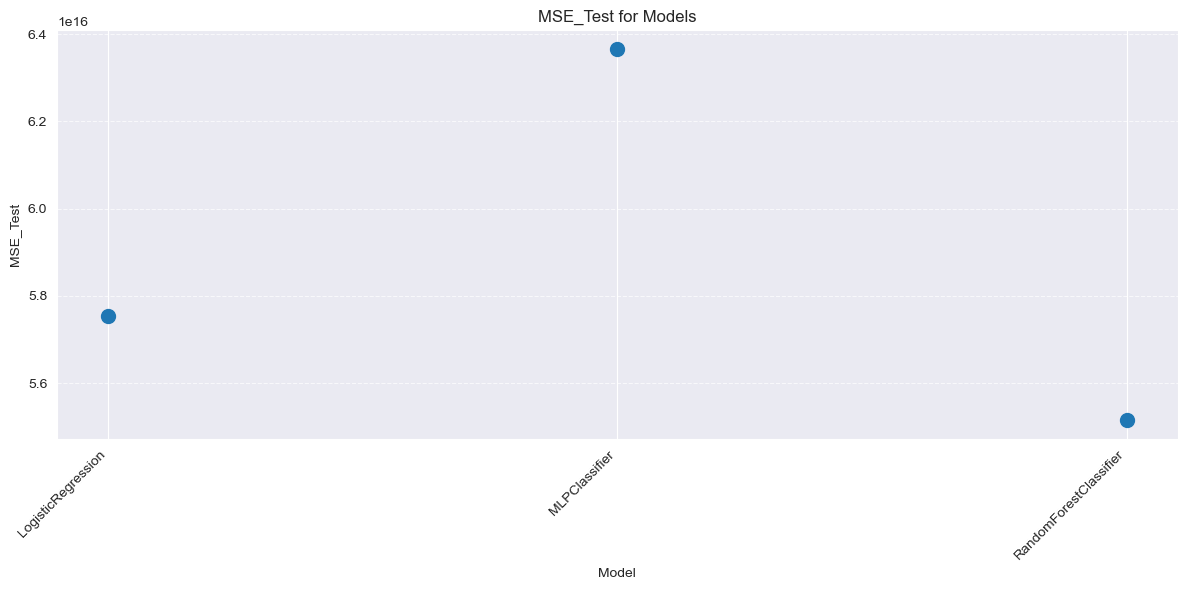

In [65]:
res.sort(key=lambda x: x[1][0] + x[1][1], reverse=False)
best_gate = res[0]

save_model_results(best_gate[0], best_gate[2], best_gate[1])

plot_metric_from_csv('estimates/gating_model_comp.csv', 'MSE_Test')

### Data balancing

In this part we will try to balance the data using Over and UnderSampling.

First we need to convert our problem into classification one. We will do it simply by trying not to guess now how many streams will the song have, but whether it will be 'viral' - so in top 10%.

In [66]:
# here we use % of the set because of set-size manipulations. By standard, we would use hard limiter - like > 100000 streams
viral_threshold = np.quantile(y_train, 0.90)

y_train_bin = (y_train > viral_threshold).astype(int)
y_test_bin = (y_test > viral_threshold).astype(int)

Ok so now what balancing does is simply to 'add' or 'remove' data that is present too many times compared to other cases. So in our case, viral songs are outliers and so if model would learn to always go for the prediction - not viral - it would be correct 90% of the time. That's why balancing is important.

There are 2 ways to go about it:
- Oversampling - adding copies or artificially-produced records to the smaller batch,
- Undersampling - removing records from bigger batch.

We will test them out.

In [67]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report

# 3. Oversampling (SMOTE) - artificially-produced data
smote = SMOTE(random_state=42)
X_train_over, y_train_over = smote.fit_resample(X_train_proc, y_train_bin)

# 4. Undersampling
undersampler = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = undersampler.fit_resample(X_train_proc, y_train_bin)

# 5. training
model_orig = LogisticRegression(max_iter=1000).fit(X_train_proc, y_train_bin)
model_over = LogisticRegression(max_iter=1000).fit(X_train_over, y_train_over)
model_under = LogisticRegression(max_iter=1000).fit(X_train_under, y_train_under)


Now for the results.

In [68]:
models = {'LogisticRegression': model_orig,
          'LogisticRegression - OverSampling': model_over,
          'LogisticRegression - UnderSampling': model_under,}

res=[]
for name, model in models.items():
    y_pred_bin = model.predict(X_test_proc)
    y_pred_train = model.predict(X_train_proc)
    t_r = classification_report(y_train_bin, y_pred_train, output_dict=True)
    train_res = (t_r['accuracy'], t_r['1']['recall'])
    t_r = classification_report(y_test_bin, y_pred_bin, output_dict=True)
    test_res = (t_r['accuracy'], t_r['1']['recall'])
    save_model_results(name, train_res, test_res, 'balancing_comp.csv', classification=True)
    res.append((name, test_res, train_res))


y_pred_orig = model_orig.predict(X_test_proc)
y_pred_over = model_over.predict(X_test_proc)
y_pred_under = model_under.predict(X_test_proc)

Saved to estimates\balancing_comp.csv
Saved to estimates\balancing_comp.csv
Saved to estimates\balancing_comp.csv


Like last time - we take best one to global results.

('LogisticRegression - UnderSampling', (0.660856134157105, 0.7079787234042553), (0.711519364448858, 0.9158415841584159))
Saved to estimates\estimated_data.csv


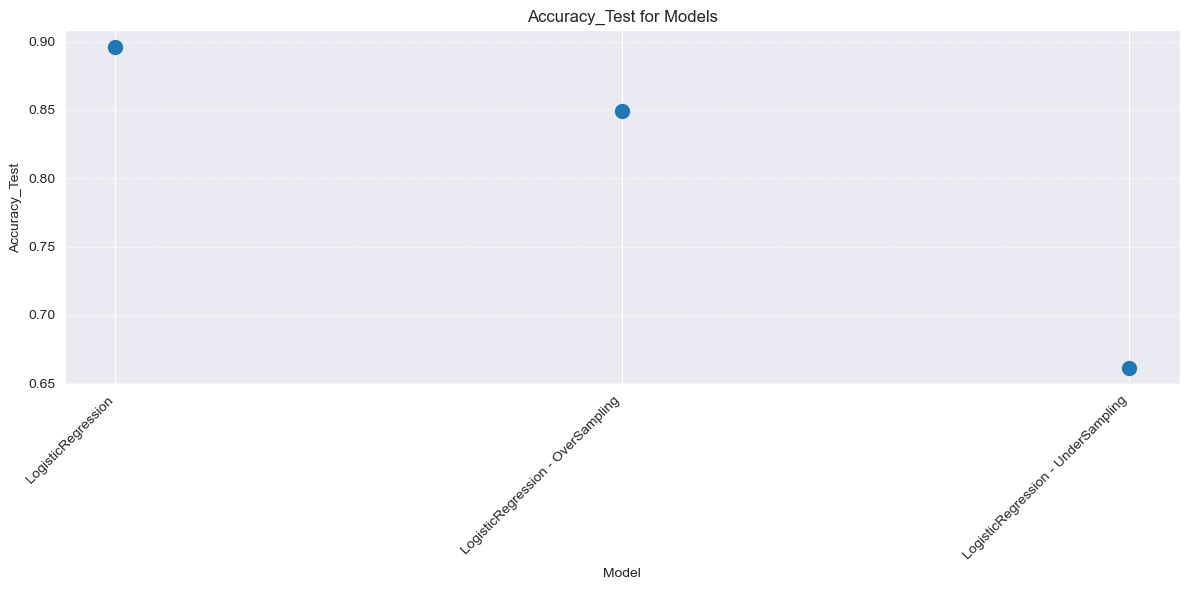

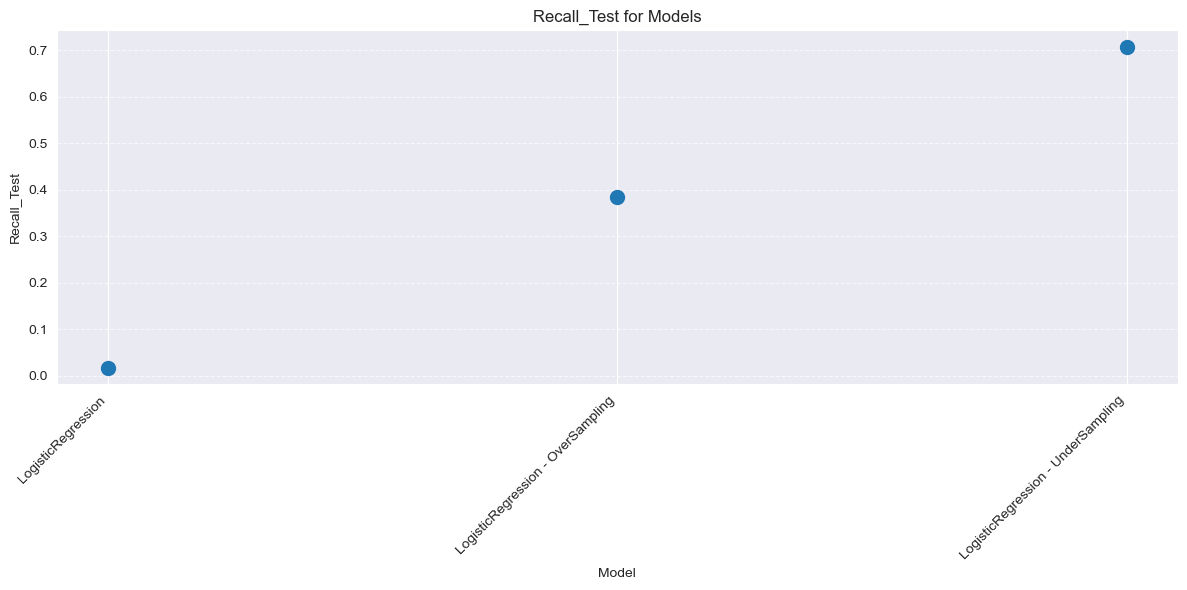

In [110]:
print(res[0])
res.sort(key=lambda x: x[1][0] + x[1][1], reverse=False)
best_bal = res[0]

save_model_results(best_bal[0], best_bal[1], best_bal[2], classification=True)

plot_metric_from_csv('estimates/balancing_comp.csv', 'Accuracy_Test', name='Balancing_Accuracy')
plot_metric_from_csv('estimates/balancing_comp.csv', 'Recall_Test', name='Balancing_Recall')

So now we can see the difference:

- For Accuracy - not balancing is best but it's because of effect previously described - this model is pretty useless, whereas UnderSampling performs badly,
- For Recall (how many of virals are recognized) - Undersampling gives the best results, but Oversampling still provides a betterment.

### Part 3 - Results

After testing few of the optimisation methods we can present the results.

#### 1 - Kfold stability testing

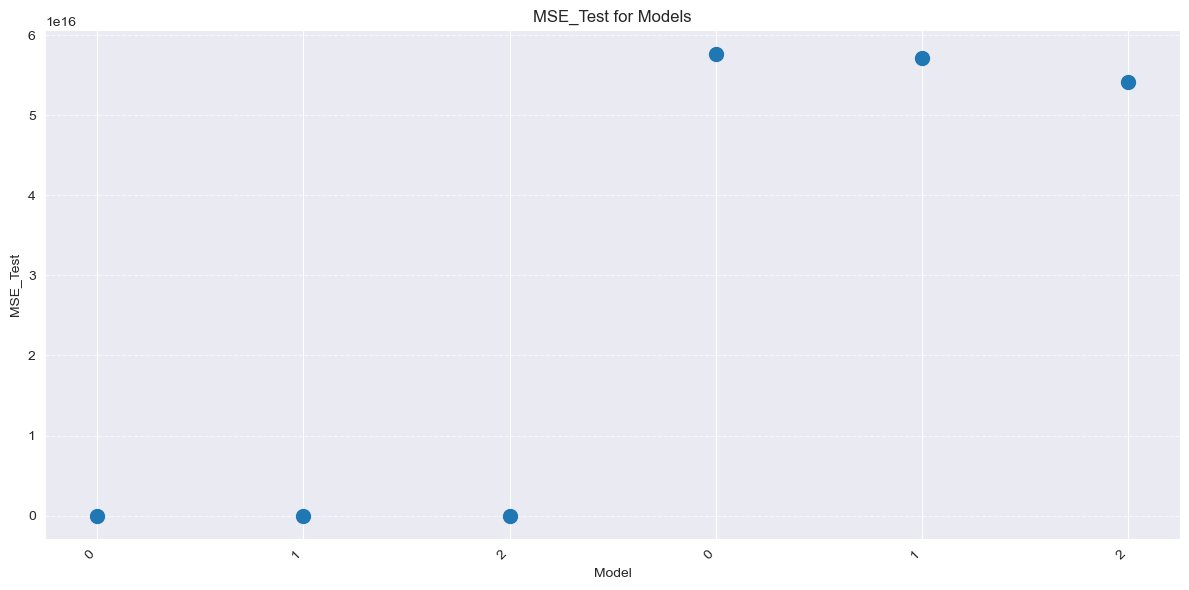

,Model,MSE_Test,R2_Test
0,0,6.608561e-01,0.707979
1,1,6.608561e-01,0.707979
2,2,6.608561e-01,0.707979
3,0,5.770326e+16,0.000000
4,1,5.708795e+16,0.000000


In [78]:
stab_test = pd.read_csv('estimates/Kfold_result.csv')
plot_metric_from_csv('estimates/Kfold_result.csv', 'MSE_Test')
stab_test.head()

As we can see - results were close to one another. This can be surprising - as we have a dataset that contains a decent amount of outliers. On the other hand they are not that popular and most songs are still pretty evenly spread across normal distribution.

#### 2 - Over - and - Underfitting testing

Our original gradient descent had a pretty convincing learning curve. Despite that we still tested it for presence of Overfitting as well as Underfitting. Quick recap:

In [80]:
from IPython.display import Image

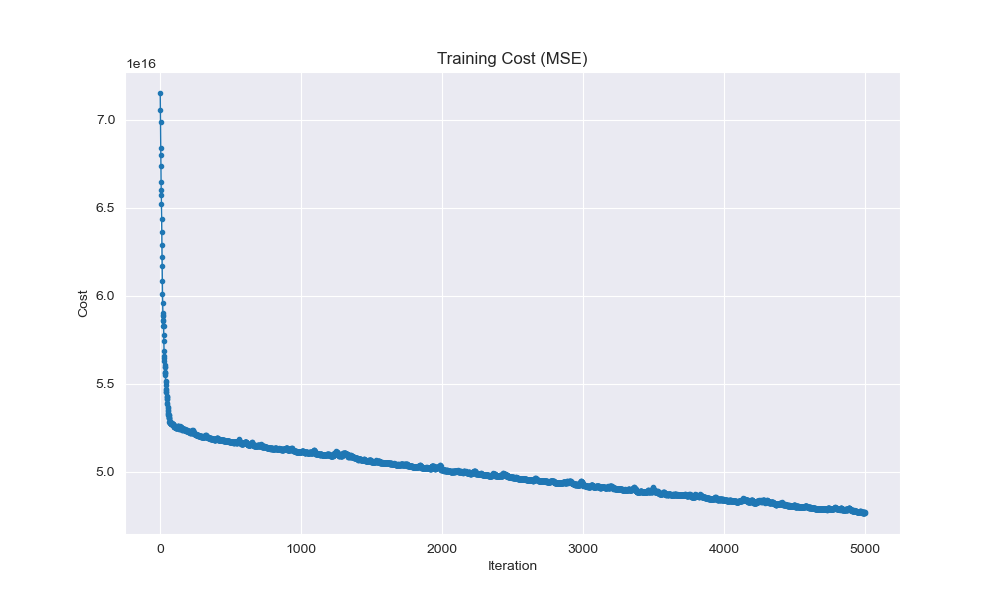

In [86]:
Image(filename='estimates/fitting_charts/Training Cost (MSE)_fit_chart.png')

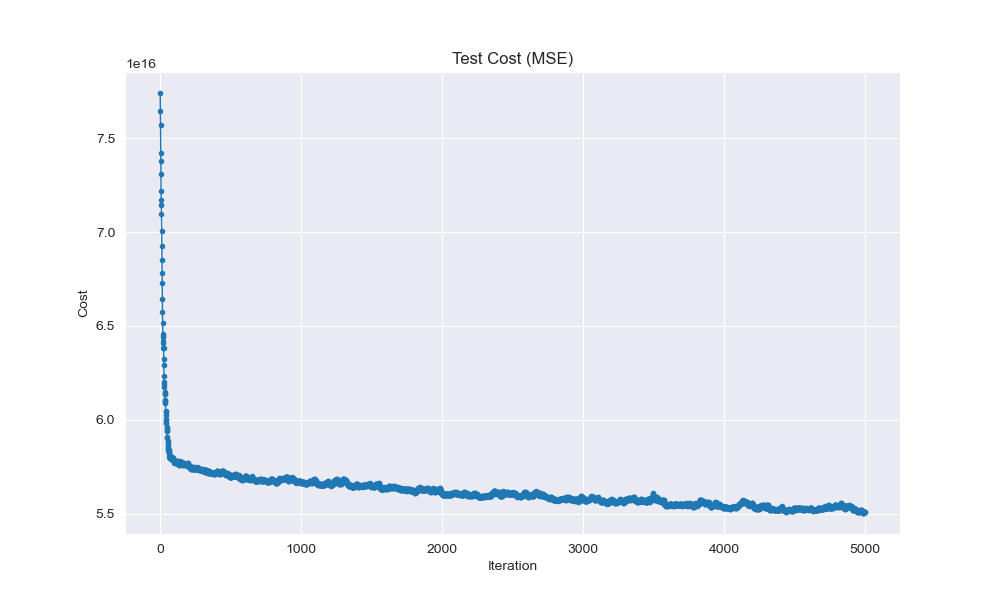

In [87]:
Image(filename='estimates/fitting_charts/Test Cost (MSE)_fit_chart.png')


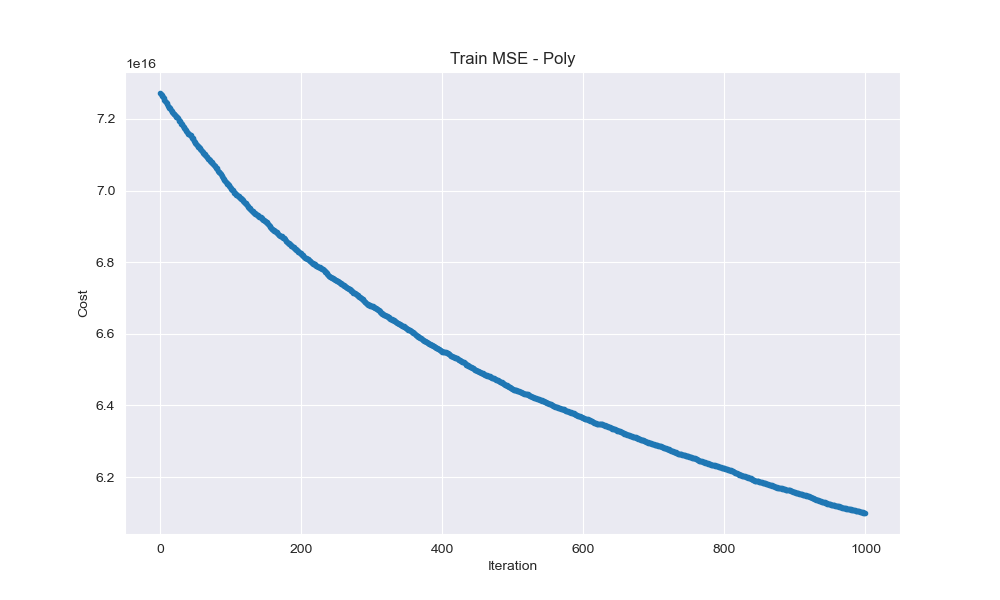

In [88]:
Image(filename='estimates/fitting_charts/Train MSE - Poly_fit_chart.png')

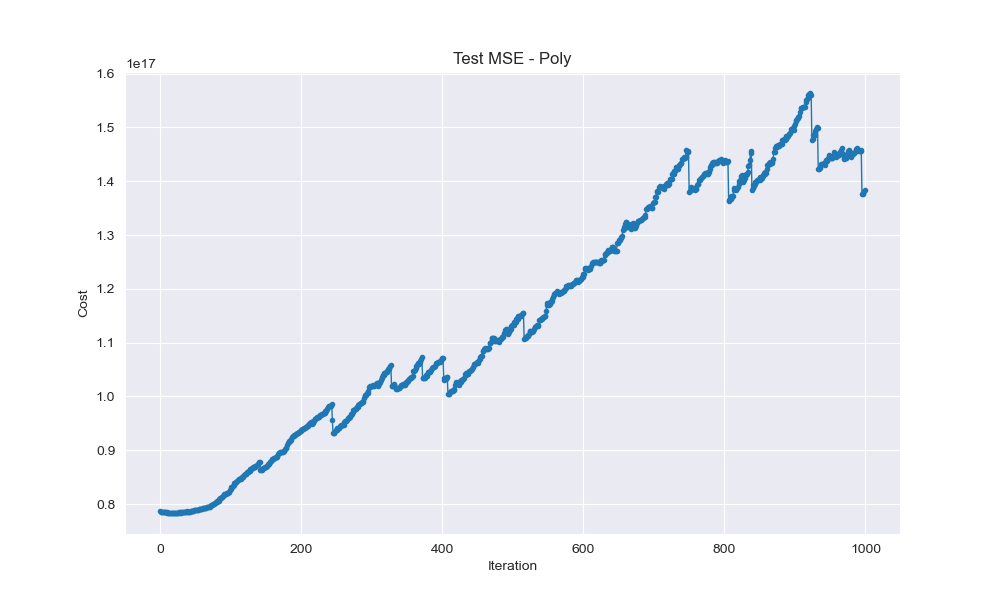

In [89]:
Image(filename='estimates/fitting_charts/Test MSE - Poly_fit_chart.png')


This is where we could see the Overfitting at it's finest - Trainig cost going steadily down, whereas Test cost kept increasing. This means our model was kept getting better at seeing these 'fake' correlations, but it was useless for the real predicition.

#### 3 - Regularisation using Lasso and Ridge

This is where we tested 2 different approaches to wages' values reduction - Lasso and Ridge. Details about them were explained in the upper part.

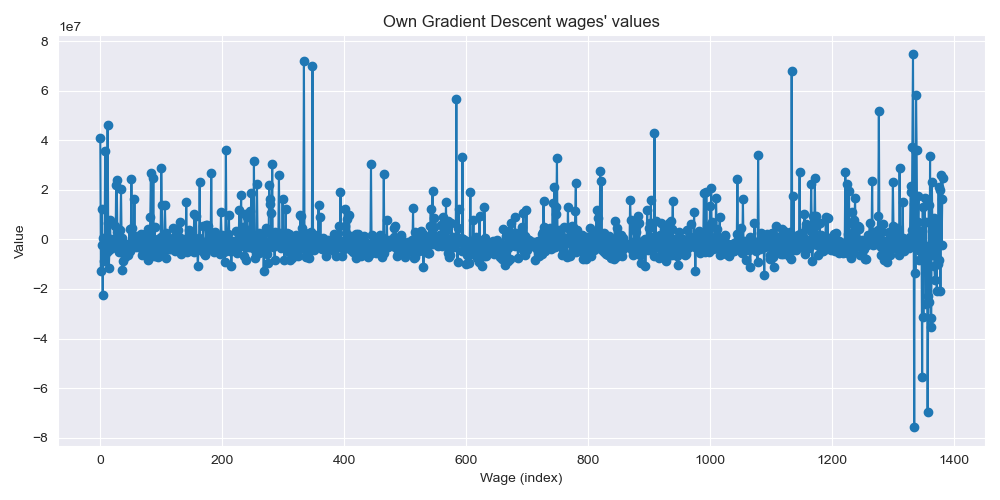

In [96]:
Image(filename="estimates/wage_charts/Own Gradient Descent wages' values_wage_chart.png")

This is how original wages look without  any regularisation.

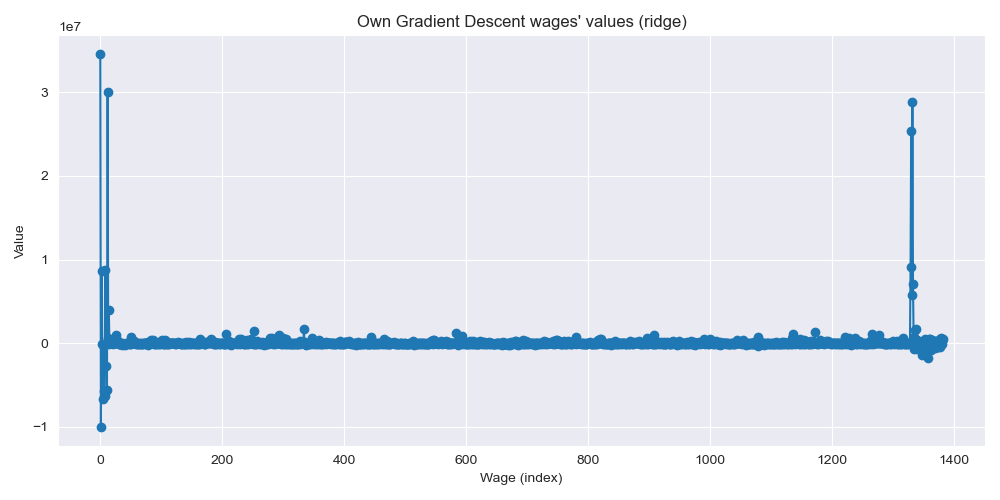

In [97]:
Image(filename="estimates/wage_charts/Own Gradient Descent wages' values (ridge)_wage_chart.png")

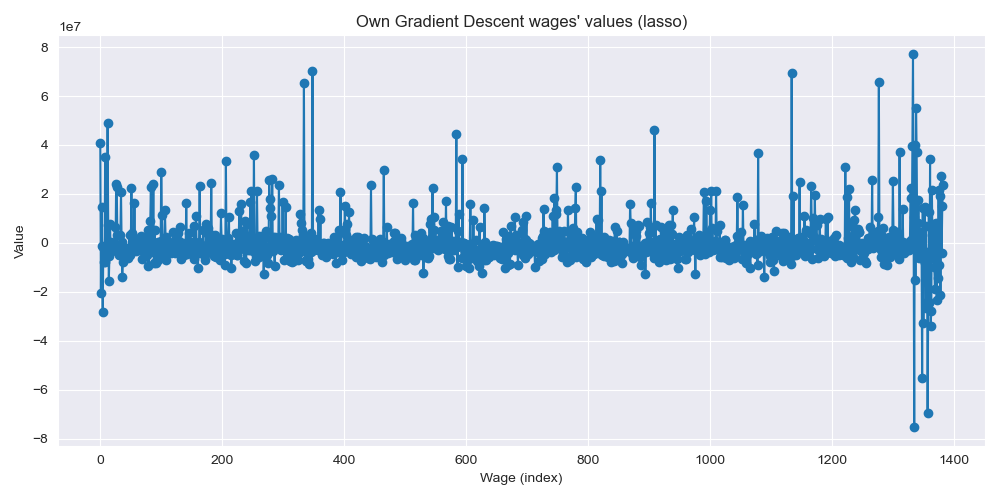

In [98]:
Image(filename="estimates/wage_charts/Own Gradient Descent wages' values (lasso)_wage_chart.png")

Looking at these charts we can pretty simply tell the difference between the two:
- Ridge extremely dampens big values - better with highly connected features,
- Lasso 'selects' important features - better when attributes are not correlated.

Now let's see learning curves.

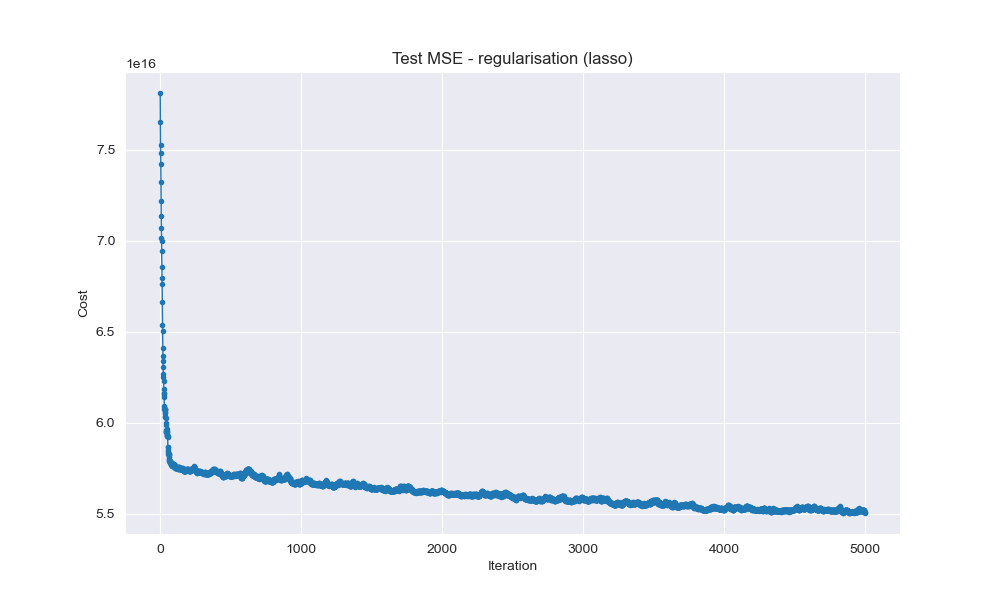

In [99]:
Image(filename='estimates/fitting_charts/Test MSE - regularisation (lasso)_fit_chart.png')

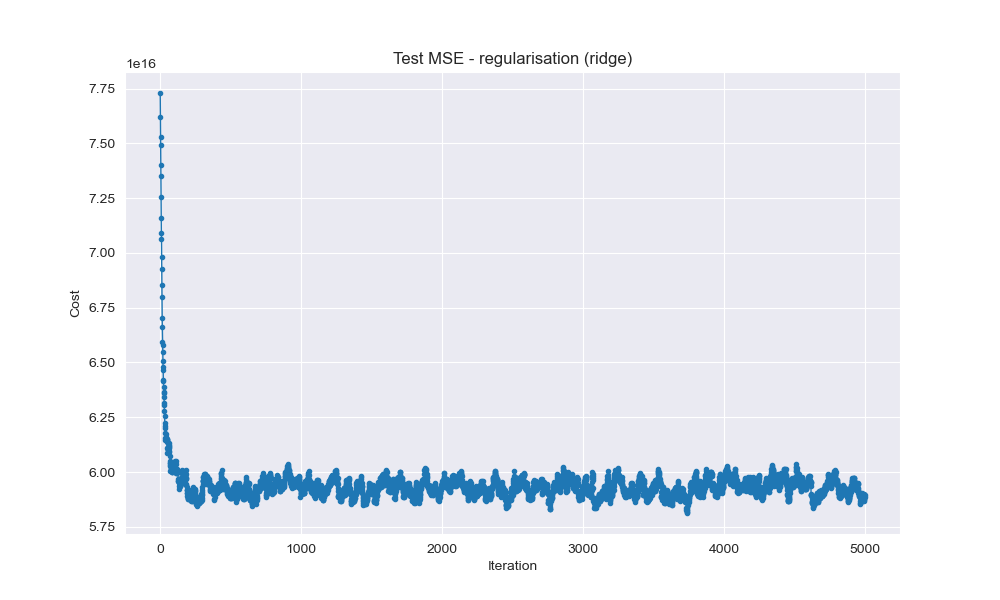

In [100]:
Image(filename='estimates/fitting_charts/Test MSE - regularisation (ridge)_fit_chart.png')

In [102]:
results = pd.read_csv('estimates/estimated_data.csv')

selected_rows = results[results["Model"].isin([
    "Own Gradient Descent with Regularisation (ridge)",
    "Own Gradient Descent with Regularisation (lasso)",
    "Own Gradient Descent"
])]

display(selected_rows)

,Model,MSE_Train,R2_Train,MSE_Test,R2_Test,Accuracy_Train,Recall_Train,Accuracy_Test,Recall_Test
6,Own Gradient Descent,4.768447e+16,0.134168,5.507504e+16,0.083595,NaN,NaN,NaN,NaN
16,Own Gradient Descent with Regularisation (ridge),5.362601e+16,0.026285,5.893728e+16,0.019331,NaN,NaN,NaN,NaN
17,Own Gradient Descent with Regularisation (lasso),4.762566e+16,0.135236,5.504187e+16,0.084147,NaN,NaN,NaN,NaN


As we can see results were pretty close. Lasso regularisation has a bit of an edge when compared to others (especially ridge). This can mean that our features are uncorrelated and lasso's algorithm eliminated some 'noise' from them.

#### 4 - Over - and - Undersampling

In this part we checked whether Over or undersampling can enhance results. Quick recap - these are techniques used to balance distribution of data (especially of categorical data). Oversampling is present, when we 'add' records to less popular group and undersampling is when we reduce the dominant data.

Why would we do this - I will forward the analogy I have already mentioned previously - If we have small amount of the outliers - in our case songs that are viral - model can always predict that this case is not the outlier. Then the model would be right most of the time, but it would be useless. That's why we use data-balancing.

In our case, I transformed our linear problem to logical one:

Now we try to predict whether the song with given attributes is viral or not - viral songs are those that contribute to 10% of the most popular ones. Of course, normally a hard threshold would be preferred, but here I used percentage based choice because of convenience.

Now this problem is logical - 1 if the song is viral or 0 if it is not.

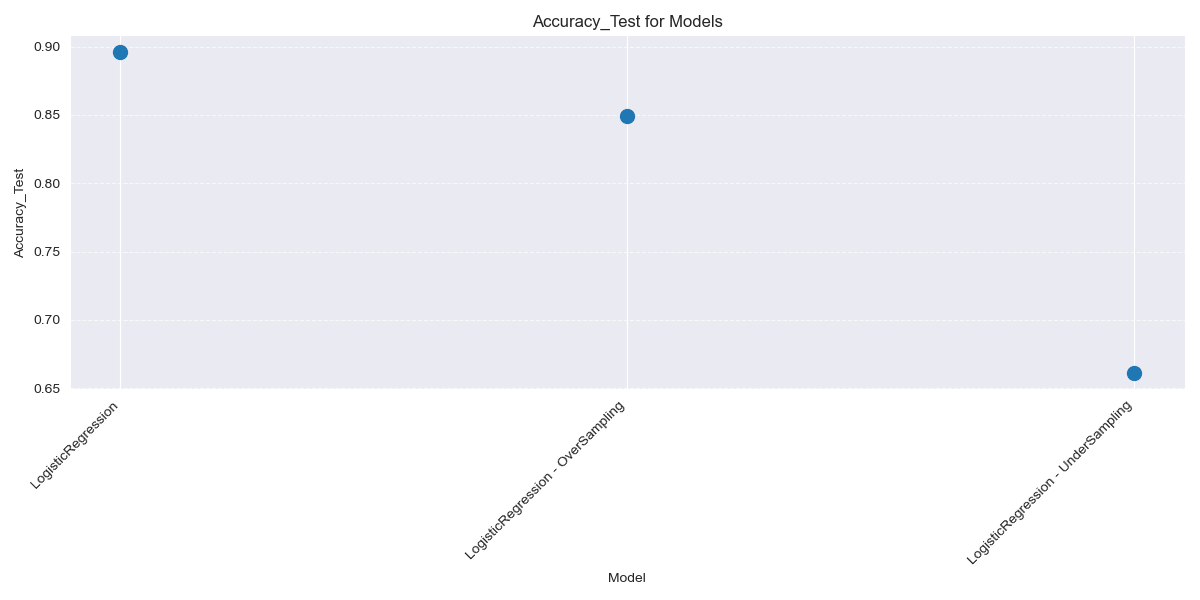

In [111]:
Image(filename='estimates/plot_charts/Balancing_Accuracy_plot_chart.png')

So as we can see this is the case that I have mentioned - on original model we have 90% accuracy because of it always predictiong false. On the other hand undersampling has the worst results.

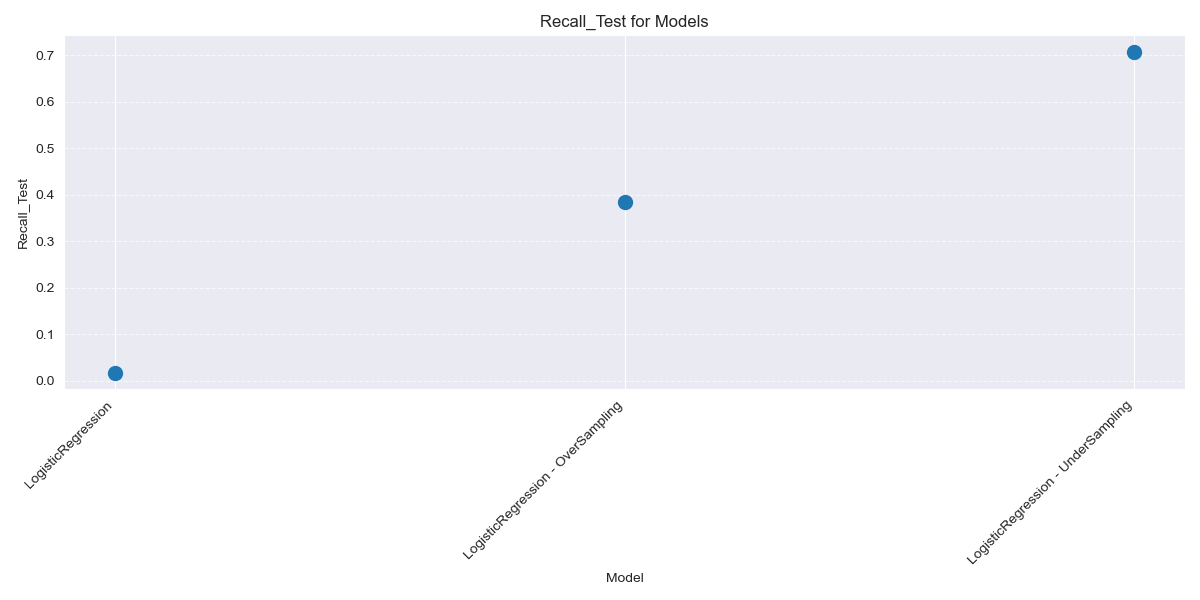

In [112]:
Image(filename='estimates/plot_charts/Balancing_Recall_plot_chart.png')

So here we can see the expected results:
- Original - have the best Accuracy, but can't really predict any outlier,
- Undersampling - can tell pretty good which one is an outlier but has a bad performace overall,
- Oversampling - is in the centre - has pretty good performance and still can predict some outliers.


#### 5 - Hyperparameters optimisation

Here we have done some hyperparameters tuning for basic models using GridSearch. This is a pretty simple, yet challenging process, because it's classified as 'black box' one (at least at it's simplest way).

Many of the models have parameters like learning rate, depth and other. By optimising them we can actually create much more accurate predictions.

In this part we have tested 3 models - Random Forest, SGD and SVR.

In [113]:

selected_rows = results[results["Model"].isin([
    "SGD Regressor tuned",
    "Random Forest tuned",
    "SVR tuned",
    'Stochastic Gradient Descent',
    "Random Forest",
    "Support Vector Regressor"

])]

display(selected_rows)

,Model,MSE_Train,R2_Train,MSE_Test,R2_Test,Accuracy_Train,Recall_Train,Accuracy_Test,Recall_Test
2,Random Forest,7.528704e+15,0.863297,5.589462e+16,0.069958,NaN,NaN,NaN,NaN
3,Support Vector Regressor,6.210356e+16,-0.127647,6.768609e+16,-0.126242,NaN,NaN,NaN,NaN
4,Stochastic Gradient Descent,1.354717e+16,0.754017,5.519307e+16,0.081632,NaN,NaN,NaN,NaN
9,SGD Regressor tuned,2.983326e+16,0.458302,5.064177e+16,0.157362,NaN,NaN,NaN,NaN
10,Random Forest tuned,7.078284e+15,0.871476,5.350835e+16,0.109664,NaN,NaN,NaN,NaN
11,SVR tuned,6.210443e+16,-0.127662,6.768710e+16,-0.126259,NaN,NaN,NaN,NaN


In [116]:
mapping = {
    'Random Forest': 'Random Forest tuned',
    'Support Vector Regressor': 'SVR tuned',
    'Stochastic Gradient Descent': 'SGD Regressor tuned'
}

for base_model, tuned_model in mapping.items():
    mse_base = results.loc[results['Model'] == base_model, 'MSE_Test'].values[0]
    mse_tuned = results.loc[results['Model'] == tuned_model, 'MSE_Test'].values[0]
    improvement = ((mse_base - mse_tuned) / mse_base) * 100
    print(f"{base_model} -> {tuned_model}: MSE Test improved by {improvement:.2f}%")

Random Forest -> Random Forest tuned: MSE Test improved by 4.27%
Support Vector Regressor -> SVR tuned: MSE Test improved by -0.00%
Stochastic Gradient Descent -> SGD Regressor tuned: MSE Test improved by 8.25%


This is an interesting result:
- Random Forest - we did see bit of a betterment,
- SVR - worst one and still the worst - possibly problem with model's architecture and not parameters,
- SGD - big improvement - due to regularisation and slow lr.

#### 6 - Ensemble methods

Ensembling is a simple concept which is based on working with each's model strong side. We used here various techniques:
- VotingRegressor - takes mean of the models' predictions,
- StackingRegressor - more advanced - trains meta-model in what wages assign to each's model prediction,
- Mixture of Experts - truly advanced - dynamically decides which model's to trust the most.

For each we used:
- Linear Regression - basic but worked well in our case,
- Random Forest - was very stable throughout,
- SVR - was the worst on it's own.

In [117]:
selected_rows = results[results["Model"].isin([
    "Voting Regressor",
    "Stacking Regressor"

])]

display(selected_rows)

,Model,MSE_Train,R2_Train,MSE_Test,R2_Test,Accuracy_Train,Recall_Train,Accuracy_Test,Recall_Test
12,Voting Regressor,1.677711e+16,0.695369,5.387604e+16,0.103546,NaN,NaN,NaN,NaN
13,Stacking Regressor,1.799949e+16,0.673174,5.315604e+16,0.115526,NaN,NaN,NaN,NaN


When it comes to MoE there was a few gating models (models that decide which estimation model to trust the most in this case), so we did testing and the best one appended to general results.

In [118]:
pd.read_csv('estimates/gating_model_comp.csv').head()

,Model,MSE_Train,R2_Train,MSE_Test,R2_Test
0,LogisticRegression,8.833510e+15,0.839605,5.753538e+16,0.042658
1,MLPClassifier,3.378345e+15,0.938658,6.365719e+16,-0.059205
2,RandomForestClassifier,4.843906e+15,0.912047,5.515030e+16,0.082343


### Best model

Finally, we can choose which way was the best, we have tested a lot of different approaches and now it is time to see them all.

In [120]:
results.head(20)

,Model,MSE_Train,R2_Train,MSE_Test,R2_Test,Accuracy_Train,Recall_Train,Accuracy_Test,Recall_Test
0,Linear Regression,1.083752e+16,0.803217,6.533906e+16,-0.087189,NaN,NaN,NaN,NaN
1,Linear Regression with PCA,4.915623e+16,0.107445,5.672073e+16,0.056213,NaN,NaN,NaN,NaN
2,Random Forest,7.528704e+15,0.863297,5.589462e+16,0.069958,NaN,NaN,NaN,NaN
3,Support Vector Regressor,6.210356e+16,-0.127647,6.768609e+16,-0.126242,NaN,NaN,NaN,NaN
4,Stochastic Gradient Descent,1.354717e+16,0.754017,5.519307e+16,0.081632,NaN,NaN,NaN,NaN
5,Own closed Linear Regression,1.083752e+16,0.803217,6.534053e+16,-0.087214,NaN,NaN,NaN,NaN
6,Own Gradient Descent,4.768447e+16,0.134168,5.507504e+16,0.083595,NaN,NaN,NaN,NaN
7,PyTorch Linear Regression,5.145619e+16,0.065683,5.684592e+16,0.054129,NaN,NaN,NaN,NaN
8,Own Gradient Descent with Regularisation,5.366853e+16,0.025513,5.892980e+16,0.019455,NaN,NaN,NaN,NaN
9,SGD Regressor tuned,2.983326e+16,0.458302,5.064177e+16,0.157362,NaN,NaN,NaN,NaN


In [126]:
from scipy.stats import rankdata

df_clean = results.dropna(subset=["MSE_Test", "R2_Test"]).copy(deep=True)

best_mse_model = df_clean.loc[df_clean["MSE_Test"].idxmin()]

best_r2_model = df_clean.loc[df_clean["R2_Test"].idxmax()]

print("Best model according to MSE_Test:")
print(best_mse_model[["Model", "MSE_Test", "R2_Test"]])

print("\nBest model according to R2_Test:")
print(best_r2_model[["Model", "MSE_Test", "R2_Test"]])

df_clean.loc[:, "MSE_rank"] = rankdata(df_clean["MSE_Test"], method="min")  # niższe MSE → lepszy ranking
df_clean.loc[:, "R2_rank"] = rankdata(-df_clean["R2_Test"], method="min")   # wyższe R² → lepszy ranking
df_clean.loc[:, "Combined_rank"] = df_clean["MSE_rank"] + df_clean["R2_rank"]


best_combined_model = df_clean.loc[df_clean["Combined_rank"].idxmin()]

print("\nBest model according to ranking (MSE + R2):")
print(best_combined_model[["Model", "MSE_Test", "R2_Test", "Combined_rank"]])

Best model according to MSE_Test:
Model       SGD Regressor tuned
MSE_Test    50641771457551552.0
R2_Test                0.157362
Name: 9, dtype: object

Best model according to R2_Test:
Model       SGD Regressor tuned
MSE_Test    50641771457551552.0
R2_Test                0.157362
Name: 9, dtype: object

Best model according to ranking (MSE + R2):
Model            SGD Regressor tuned
MSE_Test         50641771457551552.0
R2_Test                     0.157362
Combined_rank                      2
Name: 9, dtype: object


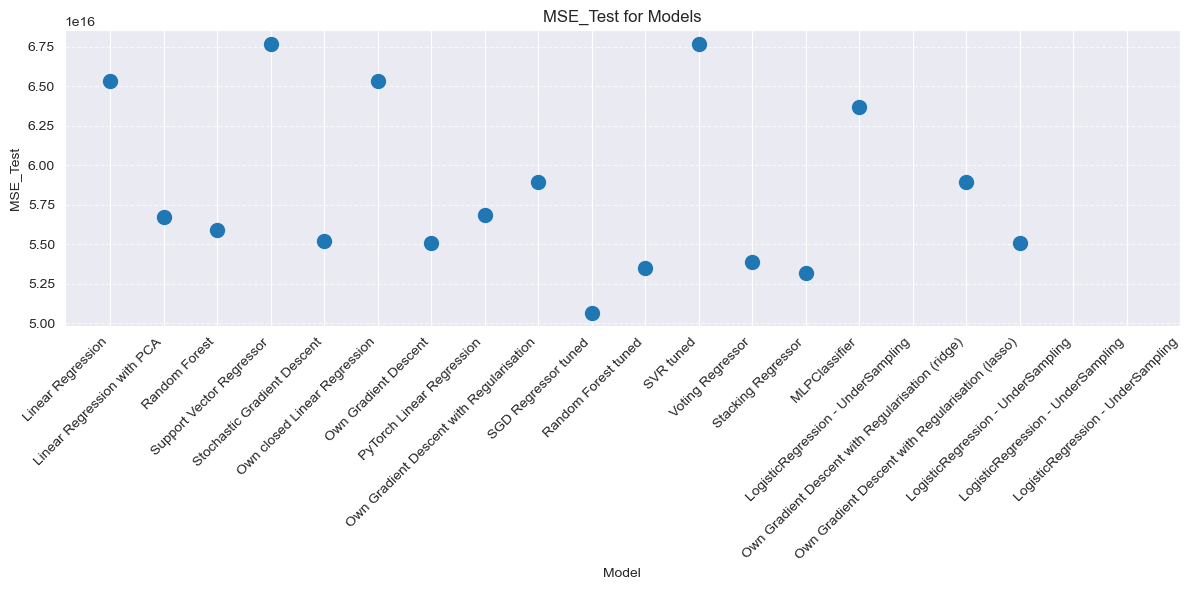

In [127]:
plot_metric_from_csv('estimates/estimated_data.csv', 'MSE_Test')

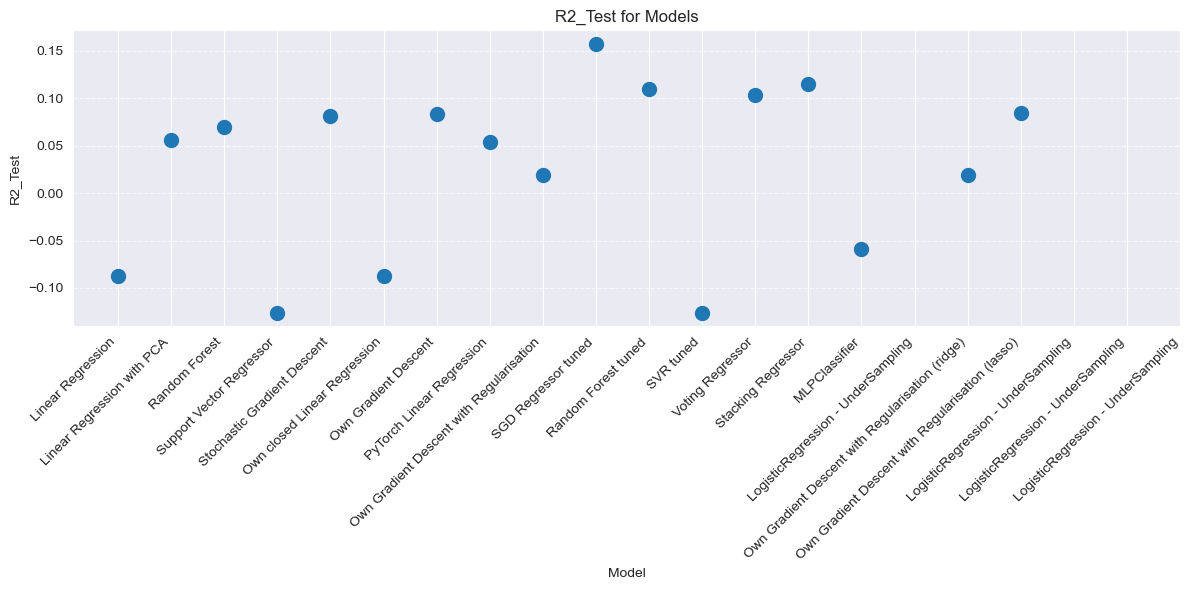

In [128]:
plot_metric_from_csv('estimates/estimated_data.csv', 'R2_Test')

So - in the end the best one turned out to be simple Stochastic Gradient Descent, just with tweaked parameters.